# Active Learning with two oracles and cold start

## 1. Настройки среды, глобальных переменных и зарузка пакетов



In [ ]:
# import os

# def restart_runtime():

#   os.kill(os.getpid(), 9)

# restart_runtime()

In [ ]:
# import sys
# modules_to_delete = [m for m in sys.modules if m.startswith("datasets") or m.startswith("huggingface_hub")]
# for m in modules_to_delete:
#     del sys.modules[m]

In [ ]:
!pip install \
  "small-text[transformers]==1.4.1" \
  "datasets<3.0.0" \
  "scikit-learn" \
  "matplotlib" \
  "pandas" "gigachat"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.9/69.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 39.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


In [ ]:
import datasets, huggingface_hub, numpy, scipy, small_text, transformers

print("datasets:", datasets.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("small-text:", small_text.__version__)
print("transformers:", transformers.__version__)


datasets: 2.21.0
huggingface_hub: 0.36.0
numpy: 2.0.2
scipy: 1.16.3
small-text: 1.4.1
transformers: 4.57.3


In [ ]:
import os
import random
import numpy as np
import torch

from dataclasses import dataclass

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = "/content/drive/MyDrive/al_two_oracles"
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "models_checkpoints")
LOG_DIR = os.path.join(PROJECT_ROOT, "logs")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

COST_HUMAN = 5.0
COST_LLM = 1.0

DEVICE: cpu


## 2. Загрузка и стандартизация датасетов

In [ ]:
@dataclass
class DatasetConfig:
    hf_name: str
    hf_config: str | None
    text_field: str
    label_field: str

DATASETS = {
    "sst2": DatasetConfig(
        hf_name="glue",
        hf_config="sst2",
        text_field="sentence",
        label_field="label",
    ),
    "ag_news": DatasetConfig(
        hf_name="ag_news",
        hf_config=None,
        text_field="text",
        label_field="label",
    ),
    "hatexplain": DatasetConfig(
        hf_name="hatexplain",
        hf_config=None,
        text_field="post",
        label_field="annotated_label"
    ),
}

POOL_SIZE = 10_000
INITIAL_LABELED = 200
BATCH_SIZE = 200
N_ITER = 10

print("=== CONFIG SUMMARY ===")
print("Seed:", SEED)
print("Cost human / LLM:", COST_HUMAN, "/", COST_LLM)
print("Pool size:", POOL_SIZE)
print("Initial labeled:", INITIAL_LABELED)
print("Batch size:", BATCH_SIZE)
print("Iterations:", N_ITER)
print("Datasets:", list(DATASETS.keys()))

=== CONFIG SUMMARY ===
Seed: 42
Cost human / LLM: 5.0 / 1.0
Pool size: 10000
Initial labeled: 200
Batch size: 200
Iterations: 10
Datasets: ['sst2', 'ag_news', 'hatexplain']


In [ ]:
from datasets import load_dataset

def load_dataset_by_key(key, cfg):
    if cfg.hf_config is None:
        ds = load_dataset(cfg.hf_name, trust_remote_code=True)
    else:
        ds = load_dataset(cfg.hf_name, cfg.hf_config, trust_remote_code=True)
    print(f"\n=== {key.upper()} DATASET ===")
    print(ds)
    return ds

raw_datasets = {}

for key, cfg in DATASETS.items():
    ds = load_dataset_by_key(key, cfg)
    raw_datasets[key] = ds


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]


=== SST2 DATASET ===
DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})


...


=== AG_NEWS DATASET ===
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


Generating train split:   0%|          | 0/15383 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1922 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1924 [00:00<?, ? examples/s]


=== HATEXPLAIN DATASET ===
DatasetDict({
    train: Dataset({
        features: ['id', 'annotators', 'rationales', 'post_tokens'],
        num_rows: 15383
    })
    validation: Dataset({
        features: ['id', 'annotators', 'rationales', 'post_tokens'],
        num_rows: 1922
    })
    test: Dataset({
        features: ['id', 'annotators', 'rationales', 'post_tokens'],
        num_rows: 1924
    })
})


In [ ]:
from collections import Counter

def standardize_dataset(ds, cfg, key):
    """
    Приводим к общему виду: поля 'text' и 'label'.
    Для hatexplain - специальная обработка.
    """
    print(f"\n[{key}] Columns in train split:", ds["train"].column_names)

    if key == "hatexplain":
        def majority_label(annotators):
            """
            annotators:
            - список словарей {'label': int, 'annotator_id': ..., 'target': ...}
            """
            if isinstance(annotators, dict):
                labels = annotators.get("label", [])
            else:
                labels = [a["label"] for a in annotators]

            if not labels:
                return -1

            return Counter(labels).most_common(1)[0][0]

        def _map_example_hatexplain(ex):
            tokens = ex["post_tokens"]
            if isinstance(tokens, list):
                text = " ".join(tokens)
            else:
                text = str(tokens)

            label = majority_label(ex["annotators"])

            return {
                "text": text,
                "label": label,
            }

        ds_mapped = ds.map(
            _map_example_hatexplain,
            remove_columns=ds["train"].column_names,
        )
        ds_mapped = ds_mapped.filter(lambda ex: ex["label"] != -1)

        return ds_mapped

    text_field = cfg.text_field
    label_field = cfg.label_field

    def _map_example_general(ex):
        return {
            "text": ex[text_field],
            "label": ex[label_field],
        }

    ds_mapped = ds.map(
        _map_example_general,
        remove_columns=ds["train"].column_names,
    )

    return ds_mapped


standardized_datasets = {}
for key, cfg in DATASETS.items():
    ds_std = standardize_dataset(raw_datasets[key], cfg, key)
    standardized_datasets[key] = ds_std



[sst2] Columns in train split: ['sentence', 'label', 'idx']


Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]


[ag_news] Columns in train split: ['text', 'label']


...

Map:   0%|          | 0/1922 [00:00<?, ? examples/s]

Map:   0%|          | 0/1924 [00:00<?, ? examples/s]

Filter:   0%|          | 0/15383 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1922 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1924 [00:00<?, ? examples/s]

In [ ]:
import numpy as np

def dataset_basic_stats(key, ds):
    print(f"\n===== BASIC STATS: {key.upper()} =====")
    splits = list(ds.keys())
    print("Splits:", splits)

    train = ds["train"]
    valid_split_name = "validation" if "validation" in ds else ("val" if "val" in ds else None)
    test_split_name = "test" if "test" in ds else None

    print("Train size:", len(train))
    if valid_split_name:
        print("Validation size:", len(ds[valid_split_name]))
    if test_split_name:
        print("Test size:", len(ds[test_split_name]))

    labels = [ex["label"] for ex in train]
    label_counts = Counter(labels)
    print("Label distribution (train):", label_counts)

    lengths = [len(str(ex["text"]).split()) for ex in train]
    print("Avg length (words):", float(np.mean(lengths)))
    print("Median length (words):", float(np.median(lengths)))
    print("95th percentile length (words):", float(np.percentile(lengths, 95)))

for key, ds_std in standardized_datasets.items():
    dataset_basic_stats(key, ds_std)



===== BASIC STATS: SST2 =====
Splits: ['train', 'validation', 'test']
Train size: 67349
Validation size: 872
Test size: 1821
Label distribution (train): Counter({1: 37569, 0: 29780})
Avg length (words): 9.409553222765
Median length (words): 7.0
95th percentile length (words): 26.0

===== BASIC STATS: AG_NEWS =====
Splits: ['train', 'test']
Train size: 120000
Test size: 7600
Label distribution (train): Counter({2: 30000, 3: 30000, 1: 30000, 0: 30000})
Avg length (words): 37.84745
Median length (words): 37.0
95th percentile length (words): 53.0

===== BASIC STATS: HATEXPLAIN =====
Splits: ['train', 'validation', 'test']
Train size: 15383
Validation size: 1922
Test size: 1924
Label distribution (train): Counter({1: 6251, 0: 4748, 2: 4384})
Avg length (words): 23.465578885783007
Median length (words): 21.0
95th percentile length (words): 49.0


In [ ]:
import pandas as pd

def show_head_as_table(key, ds, n=3):
    print(f"\n===== EXAMPLES: {key.upper()} =====")
    df = pd.DataFrame(ds["train"][:n])
    display(df)

for key, ds_std in standardized_datasets.items():
    show_head_as_table(key, ds_std, n=3)



===== EXAMPLES: SST2 =====


,label,text
0,0,hide new secretions from the parental units
1,0,"contains no wit , only labored gags"
2,1,that loves its characters and communicates som...



===== EXAMPLES: AG_NEWS =====


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2



===== EXAMPLES: HATEXPLAIN =====


,text,label
0,u really think i would not have been raped by ...,2
1,the uk has threatened to return radioactive wa...,2
2,if english is not imposition then hindi is als...,2


In [ ]:
# # Структура датасетов до стандартизации под нашу задачу

# print(raw_datasets["sst2"]["train"][0])
# print(raw_datasets["sst2"]["train"].features)

# print(raw_datasets["ag_news"]["train"][0])
# print(raw_datasets["ag_news"]["train"].features)

# print(raw_datasets["hatexplain"]["train"][0])
# print(raw_datasets["hatexplain"]["train"].features)

# # Структура датасетов после стандартизации
# print(standardized_datasets["sst2"]["train"][0])

# print(standardized_datasets["ag_news"]["train"][0])

# print(standardized_datasets["hatexplain"]["train"][0])

In [ ]:
def summarize_cold_start(history, points=(200, 400, 600, 800, 2200)):
    """
    history: список словарей из run_al_experiment_one.
    points: интересующие значения labeled.
    Возвращает словарь: {labeled: (acc, macro_f1)}.
    """
    df = pd.DataFrame(history)
    result = {}
    for n in points:
        row = df[df["labeled"] == n]
        if not row.empty:
            r = row.iloc[0]
            result[int(n)] = dict(acc=float(r["acc"]), macro_f1=float(r["macro_f1"]))
        else:
            result[int(n)] = None
    return result


## Блок 3. Подготовка модели

### 3.0 загрузка токенизатора и модели

In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

TRANSFORMER_MODEL_NAME = "distilbert-base-uncased"

tokenizer = DistilBertTokenizerFast.from_pretrained(TRANSFORMER_MODEL_NAME)
print("Tokenizer loaded.")

def get_num_labels_for_dataset(key):
    if key == "sst2":
        return 2
    elif key == "ag_news":
        return 4
    elif key == "hatexplain":
        return 3


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Tokenizer loaded.


In [ ]:
from datasets import DatasetDict

MAX_LENGTH = 128

def tokenize_dataset(ds, key):
    """
    Токенизируем датасет для sst2 / ag_news / hatexplain.
    """

    def _tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
        )

    print(f"\nTokenizing dataset: {key}")
    tokenized = ds.map(_tokenize_batch, batched=True)

    tokenized = tokenized.rename_column("label", "labels")

    tokenized.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "labels"],
    )

    return tokenized

tokenized_datasets = {}
for key, ds_std in standardized_datasets.items():
    tokenized_datasets[key] = tokenize_dataset(ds_std, key)

tokenized_datasets["sst2"]



Tokenizing dataset: sst2


Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]


Tokenizing dataset: ag_news


...


Tokenizing dataset: hatexplain


Map:   0%|          | 0/15383 [00:00<?, ? examples/s]

Map:   0%|          | 0/1922 [00:00<?, ? examples/s]

Map:   0%|          | 0/1924 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'text', 'input_ids', 'attention_mask'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['labels', 'text', 'input_ids', 'attention_mask'],
        num_rows: 872
    })
    test: Dataset({
        features: ['labels', 'text', 'input_ids', 'attention_mask'],
        num_rows: 1821
    })
})

In [ ]:
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm.auto import tqdm
import torch.nn.functional as F
import torch

def train_simple_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0
    for batch in tqdm(dataloader, desc="Train"):
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],
        )
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)


def eval_simple(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Eval"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
            )
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)
            labels = batch["labels"]
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total if total > 0 else 0.0


# ds_sst2 = tokenized_datasets["sst2"]

# train_subset = ds_sst2["train"].select(range(500))
# val_dataset = ds_sst2["validation"]

# train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=32)

# num_labels = get_num_labels_for_dataset("sst2")
# model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels).to(DEVICE)

# optimizer = AdamW(model.parameters(), lr=5e-5)

# print("Start simple training on SST-2 subset...")
# train_loss = train_simple_epoch(model, train_loader, optimizer, DEVICE)
# val_acc = eval_simple(model, val_loader, DEVICE)

# print(f"\nTrain loss (1 epoch, 500 examples): {train_loss:.4f}")
# print(f"Validation accuracy: {val_acc:.4f}")


In [ ]:
import os
import json
import pandas as pd

def save_active_learner_checkpoint(active_learner, experiment_name: str, iteration: int):
    """
    Сохраняем текущую модель (и токенизатор) на диск.
    experiment_name: строка-идентификатор эксперимента, например 'sst2_random' или 'sst2_lc'.
    iteration: номер итерации AL (0..T).
    """
    # Папка вида: models_checkpoints/sst2_random/iter_03
    exp_dir = os.path.join(CHECKPOINT_DIR, experiment_name, f"iter_{iteration:02d}")
    os.makedirs(exp_dir, exist_ok=True)

    model = getattr(active_learner.classifier, "model", None)
    if model is None:
        print("[WARN] Не удалось найти .model у active_learner.classifier, пропускаю сохранение модели.")
        return

    print(f"Saving checkpoint to: {exp_dir}")
    model.save_pretrained(exp_dir)
    tokenizer.save_pretrained(exp_dir)


def save_history(history, experiment_name: str):
    """
    Сохраняет список словарей history в JSON и CSV в LOG_DIR.
    """
    os.makedirs(LOG_DIR, exist_ok=True)
    json_path = os.path.join(LOG_DIR, f"{experiment_name}_history.json")
    csv_path = os.path.join(LOG_DIR, f"{experiment_name}_history.csv")

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(history, f, ensure_ascii=False, indent=2)

    df = pd.DataFrame(history)
    df.to_csv(csv_path, index=False)

    print(f"History saved to:\n  {json_path}\n  {csv_path}")


In [ ]:
# df = pd.read_csv("logs/sst2_random_history.csv")
# plt.plot(df["labeled"], df["acc"])

In [ ]:
import numpy as np
import torch

from transformers import AutoTokenizer
from small_text import (
    PoolBasedActiveLearner,
    TransformerBasedClassificationFactory,
    TransformerModelArguments,
    random_initialization_balanced,
)
from small_text.integrations.transformers.datasets import TransformersDataset

from small_text.query_strategies.strategies import RandomSampling, LeastConfidence
from small_text.query_strategies.bayesian import BALD
from small_text.integrations.pytorch.query_strategies import BADGE

TRANSFORMER_MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL_NAME)

def to_transformers_dataset(hf_split, num_classes, max_length=128):
    """
    hf_split: HuggingFace Dataset(split) с полями 'text' и 'label'.
    num_classes: количество классов.
    max_length: максимальная длина последовательности для токенизации.

    Возвращает small_text.TransformersDataset
    """
    texts = hf_split["text"]
    labels = np.array(hf_split["label"], dtype=np.int32)
    target_labels = np.arange(num_classes, dtype=np.int32)

    ds = TransformersDataset.from_arrays(
        texts,
        labels,
        tokenizer,
        target_labels=target_labels,
        max_length=max_length,
    )
    return ds


In [ ]:
from dataclasses import dataclass
from typing import Dict, Any, List


@dataclass
class ALConfig:
    seed: int = 42
    pool_size: int = 10000
    initial_labeled: int = 200
    batch_size: int = 200
    iterations: int = 10
    cost_human: float = 5.0
    cost_llm: float = 1.0
    max_length: int = 128
    num_epochs: int = 3
    train_batch_size: int = 16


AL_CFG = ALConfig()


def make_classifier_factory(num_classes: int, cfg: ALConfig):
    model_args = TransformerModelArguments(TRANSFORMER_MODEL_NAME)

    clf_factory = TransformerBasedClassificationFactory(
        model_args,
        num_classes,
        kwargs=dict(
            device=DEVICE,
            num_epochs=cfg.num_epochs,
            mini_batch_size=cfg.train_batch_size,
        ),
    )
    return clf_factory


def make_query_strategy(name: str, num_classes: int):
    name = name.lower()
    if name == "random":
        return RandomSampling()
    if name in ["least_conf", "uncertainty"]:
        return LeastConfidence()
    if name == "bald":
        return BALD(dropout_samples=10)
    if name == "badge":
        return BADGE(num_classes=num_classes)

    raise ValueError(f"Неизвестная стратегия: {name}")


In [ ]:
from sklearn.metrics import accuracy_score, f1_score


def subsample_pool(hf_train_split, pool_size: int, seed: int):
    """Сэмплируем pool_size из train."""
    n = len(hf_train_split)
    pool_size = min(pool_size, n)
    rng = np.random.default_rng(seed)
    indices = np.arange(n)
    rng.shuffle(indices)
    selected = indices[:pool_size]
    return hf_train_split.select(selected.tolist()), selected


def get_eval_split(ds_std):
    if "validation" in ds_std:
        return ds_std["validation"], "validation"
    else:
        return ds_std["test"], "test"


def evaluate_on_test(active_learner, test_ds):
    y_pred = active_learner.classifier.predict(test_ds)
    y_true = test_ds.y

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    return dict(acc=acc, macro_f1=macro_f1)


def run_al_experiment_one(
    dataset_key: str,
    standardized_datasets: Dict[str, Any],
    strategy_name: str,
    cfg: ALConfig = AL_CFG,
    experiment_name: str | None = None,
    save_checkpoints: bool = False,
    save_history_flag: bool = True,
):
    """
    dataset_key: 'sst2' / 'ag_news' / 'hatexplain'
    strategy_name: 'random', 'least_conf', 'bald', 'badge'
    """
    if experiment_name is None:
        experiment_name = f"{dataset_key}_{strategy_name}"

    print(f"\n=== AL EXPERIMENT: dataset={dataset_key}, strategy={strategy_name} ===")

    ds_std = standardized_datasets[dataset_key]
    train_hf = ds_std["train"]
    eval_hf, eval_name = get_eval_split(ds_std)

    num_classes = len(set(train_hf["label"]))
    print(f"Num classes: {num_classes}, eval split: {eval_name}")

    pool_hf, pool_indices = subsample_pool(train_hf, cfg.pool_size, cfg.seed)
    print(f"Pool size (subsampled): {len(pool_hf)} (original train: {len(train_hf)})")

    pool_ds = to_transformers_dataset(pool_hf, num_classes, max_length=cfg.max_length)
    test_ds = to_transformers_dataset(eval_hf, num_classes, max_length=cfg.max_length)

    clf_factory = make_classifier_factory(num_classes, cfg)
    query_strategy = make_query_strategy(strategy_name, num_classes)

    active_learner = PoolBasedActiveLearner(clf_factory, query_strategy, pool_ds)

    # initialization
    indices_initial = random_initialization_balanced(
        pool_ds.y, n_samples=cfg.initial_labeled
    )
    y_initial = np.array([pool_ds.y[i] for i in indices_initial])
    active_learner.initialize_data(indices_initial, y_initial)

    print(f"Initial labeled: {len(indices_initial)}")

    history: List[Dict[str, Any]] = []

    # AL-iterations
    indices_labeled = indices_initial.copy()

    for it in range(cfg.iterations + 1):
        metrics = evaluate_on_test(active_learner, test_ds)
        labeled_count = len(indices_labeled)

        #  oracle = human
        total_cost_human = labeled_count * cfg.cost_human
        total_cost_llm = labeled_count * cfg.cost_llm

        step_info = dict(
            iter=it,
            labeled=labeled_count,
            acc=metrics["acc"],
            macro_f1=metrics["macro_f1"],
            cost_human=total_cost_human,
            cost_llm=total_cost_llm,
        )
        history.append(step_info)

        print(
            f"[Iter {it:02d}] labeled={labeled_count:4d} | "
            f"acc={metrics['acc']:.4f} | macro_f1={metrics['macro_f1']:.4f} | "
            f"cost_human={total_cost_human:.1f}"
        )

        if save_checkpoints:
            save_active_learner_checkpoint(active_learner, experiment_name, iteration=it)

        if it == cfg.iterations:
            break

        queried_indices = active_learner.query(num_samples=cfg.batch_size)

        y_queried = pool_ds.y[queried_indices]
        active_learner.update(y_queried)

        indices_labeled = np.concatenate([indices_labeled, queried_indices])
    if save_history_flag:
      save_history(history, experiment_name)

    return history


In [ ]:
def run_all_strategies_for_dataset(
    dataset_key: str,
    standardized_datasets: Dict[str, Any],
    cfg: ALConfig,
    prefix: str,
):
    """
    Запускает random / least_conf / bald / badge для одного датасета.
    prefix — префикс для имени эксперимента в логах (например, 'ag_news' или 'hatexplain').
    """
    histories = {}

    for strategy_name in ["random", "least_conf", "bald", "badge"]:
        experiment_name = f"{prefix}_{strategy_name}"
        print(f"\n=== AL EXPERIMENT: dataset={dataset_key}, strategy={strategy_name} ===")

        history = run_al_experiment_one(
            dataset_key=dataset_key,
            standardized_datasets=standardized_datasets,
            strategy_name=strategy_name,
            cfg=cfg,
            experiment_name=experiment_name,
        )

        histories[strategy_name] = history

    return histories


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_history(experiment_name: str, title_prefix: str):
    csv_path = os.path.join(LOG_DIR, f"{experiment_name}_history.csv")
    df = pd.read_csv(csv_path)

    # 1. Accuracy vs число размеченных объектов
    plt.plot(df["labeled"], df["acc"], marker="o")
    plt.xlabel("Число размеченных объектов")
    plt.ylabel("Accuracy (validation)")
    plt.title(f"{title_prefix}: Accuracy vs #labeled")
    plt.grid(True)
    plt.show()

    # 2. Accuracy vs стоимость
    plt.plot(df["cost_human"], df["acc"], marker="o")
    plt.xlabel("Стоимость (человеческая разметка)")
    plt.ylabel("Accuracy (validation)")
    plt.title(f"{title_prefix}: Accuracy vs cost")
    plt.grid(True)
    plt.show()


In [ ]:
from transformers import DistilBertForSequenceClassification

if not hasattr(DistilBertForSequenceClassification, "_orig_forward"):
    DistilBertForSequenceClassification._orig_forward = DistilBertForSequenceClassification.forward

def _forward_patched(self, input_ids=None, attention_mask=None, **kwargs):
    return DistilBertForSequenceClassification._orig_forward(
        self,
        input_ids=input_ids,
        attention_mask=attention_mask,
        **{k: v for k, v in kwargs.items() if k != "token_type_ids"}
    )

DistilBertForSequenceClassification.forward = _forward_patched

print("Patched DistilBertForSequenceClassification.forward (idempotent).")

Patched DistilBertForSequenceClassification.forward (idempotent).


### 3.1 SST-2 Базовые стратегии


#### 3.1.1 SST-2, стратегия Random Sampling

In [ ]:
# history_sst2_random = run_al_experiment_one(
    dataset_key="sst2",
    standardized_datasets=standardized_datasets,
    strategy_name="random",
    cfg=AL_CFG,
    experiment_name="sst2_random"
)



=== AL EXPERIMENT: dataset=sst2, strategy=random ===
Num classes: 2, eval split: validation
Pool size (subsampled): 10000 (original train: 67349)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


Initial labeled: 200
[Iter 00] labeled= 200 | acc=0.5906 | macro_f1=0.5136 | cost_human=1000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_random/iter_00
[Iter 01] labeled= 400 | acc=0.8349 | macro_f1=0.8346 | cost_human=2000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_random/iter_01
[Iter 02] labeled= 600 | acc=0.8291 | macro_f1=0.8289 | cost_human=3000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_random/iter_02
[Iter 03] labeled= 800 | acc=0.8417 | macro_f1=0.8415 | cost_human=4000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_random/iter_03
[Iter 04] labeled=1000 | acc=0.8463 | macro_f1=0.8463 | cost_human=5000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_random/iter_04
[Iter 05] labeled=1200 | acc=0.8452 | macro_f1=0.8451 | cost_human=6000.0
Saving checkpoint to: /content/drive/MyD

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_sst2_random =  pd.read_csv("/content/drive/MyDrive/al_two_oracles/logs/sst2_random_history.csv")


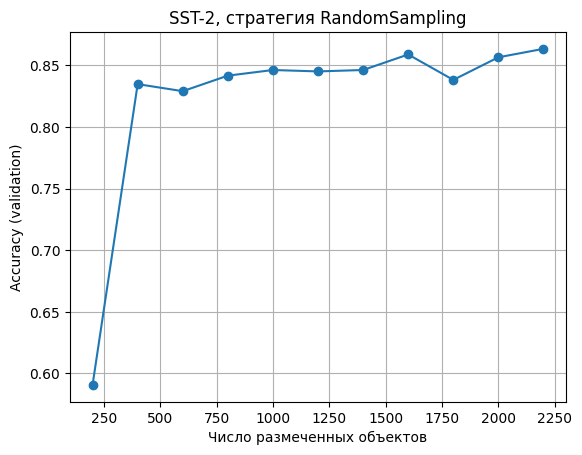

In [ ]:
plt.plot(df_sst2_random["labeled"], df_sst2_random["acc"], marker="o")
plt.xlabel("Число размеченных объектов")
plt.ylabel("Accuracy (validation)")
plt.title("SST-2, стратегия RandomSampling")
plt.grid(True)
plt.show()

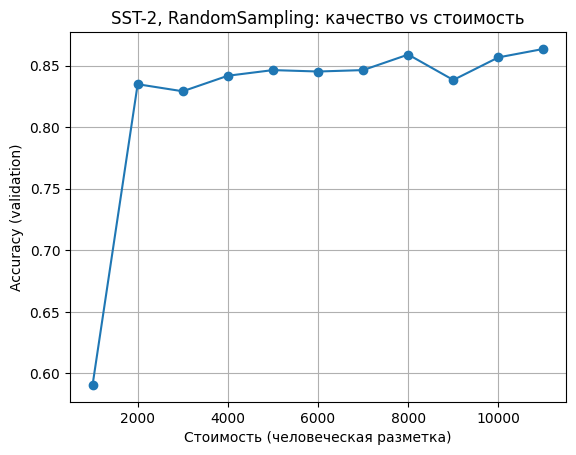

In [ ]:
plt.plot(df_sst2_random["cost_human"], df_sst2_random["acc"], marker="o")
plt.xlabel("Стоимость (человеческая разметка)")
plt.ylabel("Accuracy (validation)")
plt.title("SST-2, RandomSampling: качество vs стоимость")
plt.grid(True)
plt.show()

```python
=== AL EXPERIMENT: dataset=sst2, strategy=random ===
Num classes: 2, eval split: validation
Pool size (subsampled): 10000 (original train: 67349)

 483/483 [00:00<00:00, 45.0kB/s]
tokenizer_config.json: 100%
 48.0/48.0 [00:00<00:00, 5.48kB/s]
vocab.txt: 100%
 232k/232k [00:00<00:00, 1.42MB/s]
tokenizer.json: 100%
 466k/466k [00:00<00:00, 5.56MB/s]
model.safetensors: 100%
 268M/268M [00:01<00:00, 226MB/s]
Initial labeled: 200
[Iter 00] labeled= 200 | acc=0.6388 | macro_f1=0.6032 | cost_human=1000.0
[Iter 01] labeled= 400 | acc=0.7420 | macro_f1=0.7329 | cost_human=2000.0
[Iter 02] labeled= 600 | acc=0.8326 | macro_f1=0.8324 | cost_human=3000.0
[Iter 03] labeled= 800 | acc=0.8303 | macro_f1=0.8298 | cost_human=4000.0
[Iter 04] labeled=1000 | acc=0.8394 | macro_f1=0.8394 | cost_human=5000.0
[Iter 05] labeled=1200 | acc=0.8452 | macro_f1=0.8452 | cost_human=6000.0
[Iter 06] labeled=1400 | acc=0.8417 | macro_f1=0.8414 | cost_human=7000.0
[Iter 07] labeled=1600 | acc=0.8544 | macro_f1=0.8543 | cost_human=8000.0
[Iter 08] labeled=1800 | acc=0.8589 | macro_f1=0.8588 | cost_human=9000.0
[Iter 09] labeled=2000 | acc=0.8601 | macro_f1=0.8595 | cost_human=10000.0
[Iter 10] labeled=2200 | acc=0.8624 | macro_f1=0.8624 | cost_human=11000.0
```

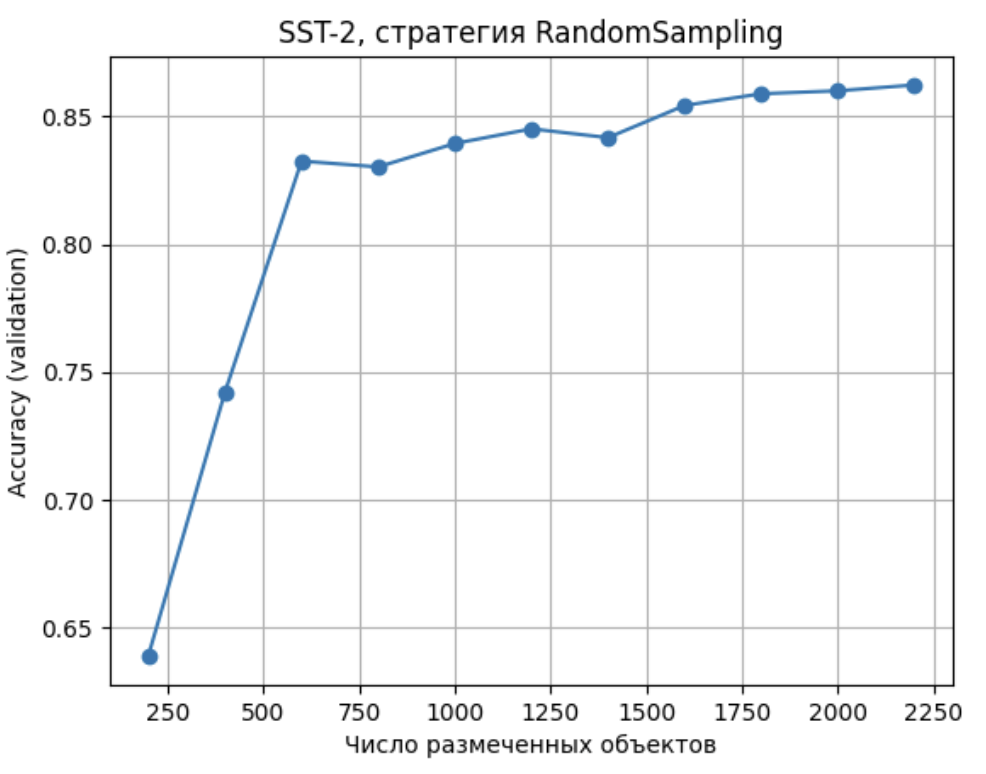


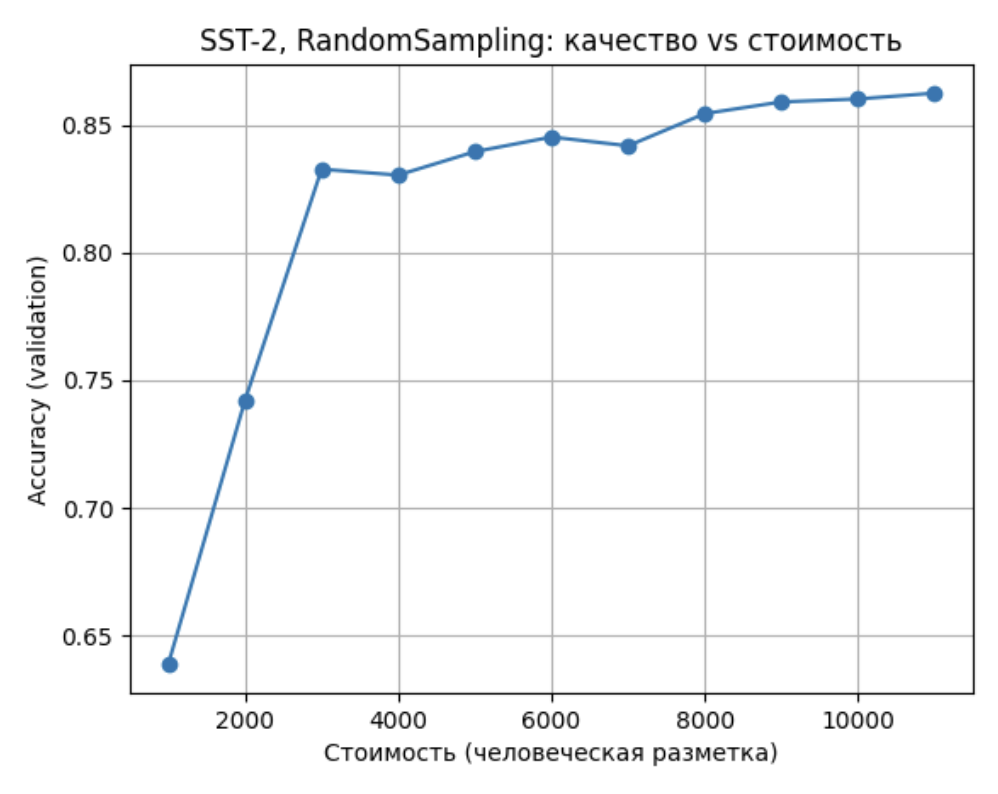

#### 3.1.2 SST-2, стратегия Least Confidence (Uncertainty Sampling)

In [ ]:
history_sst2_lc = run_al_experiment_one(
    dataset_key="sst2",
    standardized_datasets=standardized_datasets,
    strategy_name="least_conf",
    cfg=AL_CFG,
    experiment_name="lc"
)


In [ ]:
# history_sst2_lc = pd.DataFrame(history_sst2_random)
# history_sst2_lc
df_lc = pd.read_csv("/content/drive/MyDrive/al_two_oracles/logs/lc_history.csv")


In [ ]:
plt.plot(df_lc["labeled"], df_lc["acc"], marker="o")
plt.xlabel("Число размеченных объектов")
plt.ylabel("Accuracy (validation)")
plt.title("SST-2, стратегия Least Confidence")
plt.grid(True)
plt.show()

In [ ]:
plt.plot(df_lc["cost_human"], df_lc["acc"], marker="o")
plt.xlabel("Стоимость (человеческая разметка)")
plt.ylabel("Accuracy (validation)")
plt.title("SST-2, Least Confidence: качество vs стоимость")
plt.grid(True)
plt.show()

#### 3.1.3 SST-2, стратегия BALD (MC Dropout)

In [ ]:
history_sst2_bald = run_al_experiment_one(
    dataset_key="sst2",
    standardized_datasets=standardized_datasets,
    strategy_name="bald",
    cfg=AL_CFG,
    experiment_name="sst2_bald",
)


=== AL EXPERIMENT: dataset=sst2, strategy=bald ===
Num classes: 2, eval split: validation
Pool size (subsampled): 10000 (original train: 67349)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


Initial labeled: 200
[Iter 00] labeled= 200 | acc=0.4966 | macro_f1=0.3416 | cost_human=1000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_bald/iter_00


/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1024: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


[Iter 01] labeled= 400 | acc=0.8222 | macro_f1=0.8221 | cost_human=2000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_bald/iter_01


...

[Iter 08] labeled=1800 | acc=0.8647 | macro_f1=0.8646 | cost_human=9000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_bald/iter_08


/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1024: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


[Iter 09] labeled=2000 | acc=0.8761 | macro_f1=0.8761 | cost_human=10000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_bald/iter_09


/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1024: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


[Iter 10] labeled=2200 | acc=0.8647 | macro_f1=0.8645 | cost_human=11000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_bald/iter_10
History saved to:
  /content/drive/MyDrive/al_two_oracles/logs/sst2_bald_history.json
  /content/drive/MyDrive/al_two_oracles/logs/sst2_bald_history.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# history_sst2_bald = pd.DataFrame(history_sst2_bald)
# print(history_sst2_bald)
df_bald = pd.read_csv("/content/drive/MyDrive/al_two_oracles/logs/sst2_bald_history.csv")


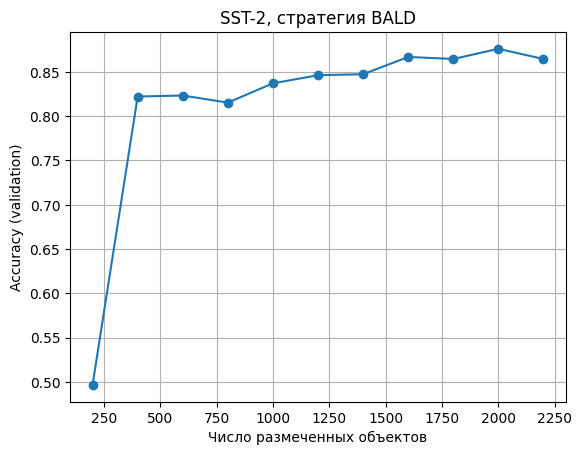

In [ ]:
plt.plot(df_bald["labeled"], df_bald["acc"], marker="o")
plt.xlabel("Число размеченных объектов")
plt.ylabel("Accuracy (validation)")
plt.title("SST-2, стратегия BALD")
plt.grid(True)
plt.show()

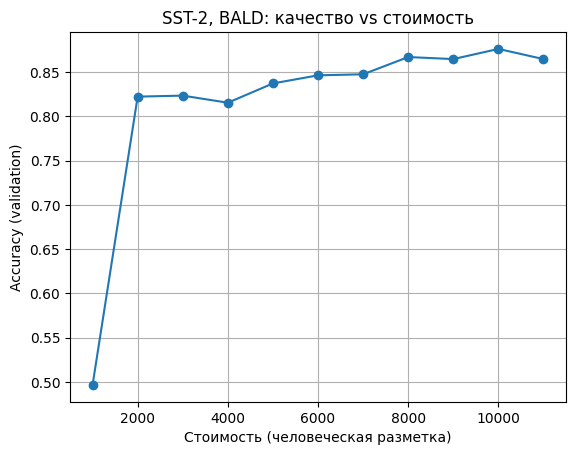

In [ ]:
plt.plot(df_bald["cost_human"], df_bald["acc"], marker="o")
plt.xlabel("Стоимость (человеческая разметка)")
plt.ylabel("Accuracy (validation)")
plt.title("SST-2, BALD: качество vs стоимость")
plt.grid(True)
plt.show()

#### 3.1.4  SST-2, стратегия BADGE

In [ ]:
from transformers import DistilBertForSequenceClassification

if not hasattr(DistilBertForSequenceClassification, "_orig_forward"):
    DistilBertForSequenceClassification._orig_forward = DistilBertForSequenceClassification.forward

def _forward_patched(self, input_ids=None, attention_mask=None, **kwargs):
    return DistilBertForSequenceClassification._orig_forward(
        self,
        input_ids=input_ids,
        attention_mask=attention_mask,
        **{k: v for k, v in kwargs.items() if k != "token_type_ids"}
    )

DistilBertForSequenceClassification.forward = _forward_patched

print("Patched DistilBertForSequenceClassification.forward (idempotent).")


Patched DistilBertForSequenceClassification.forward (idempotent).


In [ ]:
history_sst2_badge = run_al_experiment_one(
    dataset_key="sst2",
    standardized_datasets=standardized_datasets,
    strategy_name="badge",
    cfg=AL_CFG,
    experiment_name="sst2_badge",
)


=== AL EXPERIMENT: dataset=sst2, strategy=badge ===
Num classes: 2, eval split: validation
Pool size (subsampled): 10000 (original train: 67349)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

[Iter 08] labeled=1800 | acc=0.8532 | macro_f1=0.8532 | cost_human=9000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_badge/iter_08


100%|██████████| 10000/10000 [00:34<00:00, 289.81it/s]


[Iter 09] labeled=2000 | acc=0.8567 | macro_f1=0.8564 | cost_human=10000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_badge/iter_09


100%|██████████| 10000/10000 [00:33<00:00, 295.68it/s]


[Iter 10] labeled=2200 | acc=0.8509 | macro_f1=0.8509 | cost_human=11000.0
Saving checkpoint to: /content/drive/MyDrive/al_two_oracles/models_checkpoints/sst2_badge/iter_10
History saved to:
  /content/drive/MyDrive/al_two_oracles/logs/sst2_badge_history.json
  /content/drive/MyDrive/al_two_oracles/logs/sst2_badge_history.csv


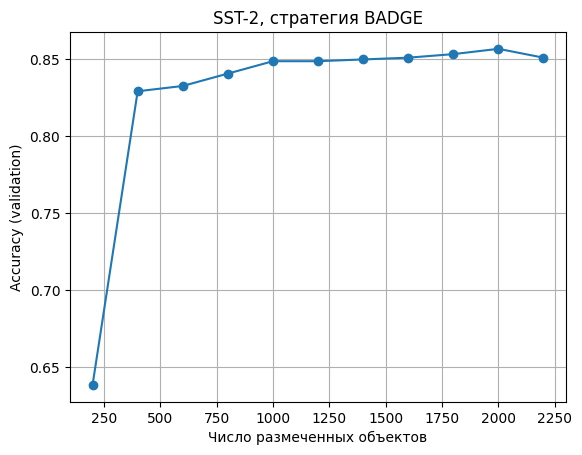

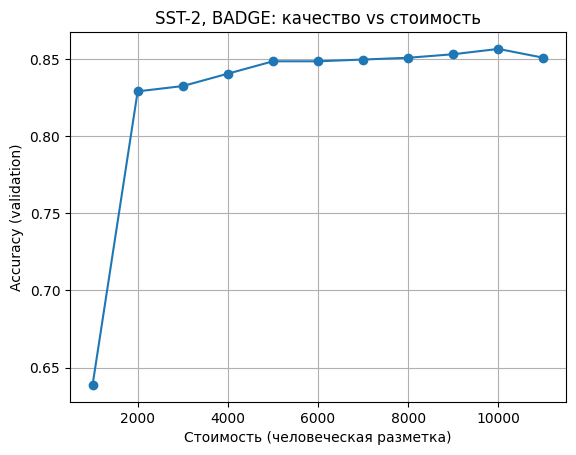

In [ ]:
import matplotlib.pyplot as plt
df_badge = pd.read_csv("/content/drive/MyDrive/al_two_oracles/logs/sst2_badge_history.csv")

plt.plot(df_badge["labeled"], df_badge["acc"], marker="o")
plt.xlabel("Число размеченных объектов")
plt.ylabel("Accuracy (validation)")
plt.title("SST-2, стратегия BADGE")
plt.grid(True)
plt.show()

plt.plot(df_badge["cost_human"], df_badge["acc"], marker="o")
plt.xlabel("Стоимость (человеческая разметка)")
plt.ylabel("Accuracy (validation)")
plt.title("SST-2, BADGE: качество vs стоимость")
plt.grid(True)
plt.show()

#### 3.1.5 сравнение результатов по датасету SST классических методов

In [ ]:
history_sst2_random = pd.read_csv("/content/drive/MyDrive/al_two_oracles/logs/sst2_random_history.csv")
history_sst2_lc = pd.read_csv("/content/drive/MyDrive/al_two_oracles/logs/lc_history.csv")
history_sst2_bald = pd.read_csv("/content/drive/MyDrive/al_two_oracles/logs/sst2_bald_history.csv")
history_sst2_badge = pd.read_csv("/content/drive/MyDrive/al_two_oracles/logs/sst2_badge_history.csv")

In [ ]:
summary_rand = summarize_cold_start(history_sst2_random)
summary_lc = summarize_cold_start(history_sst2_lc)
summary_bald = summarize_cold_start(history_sst2_bald)
summary_badge = summarize_cold_start(history_sst2_badge)

summary_rand, summary_lc, summary_bald, summary_badge

({200: {'acc': 0.5905963302752294, 'macro_f1': 0.5135684987694832},
  400: {'acc': 0.8348623853211009, 'macro_f1': 0.8346109469092289},
  600: {'acc': 0.8291284403669725, 'macro_f1': 0.8289392437294532},
  800: {'acc': 0.841743119266055, 'macro_f1': 0.8415021574546777},
  2200: {'acc': 0.8635321100917431, 'macro_f1': 0.8634802228668785}},
 {200: {'acc': 0.7580275229357798, 'macro_f1': 0.7558152343413029},
  400: {'acc': 0.8211009174311926, 'macro_f1': 0.8210858585858586},
  600: {'acc': 0.8325688073394495, 'macro_f1': 0.832419824458871},
  800: {'acc': 0.8474770642201835, 'macro_f1': 0.8474608149645602},
  2200: {'acc': 0.8715596330275229, 'macro_f1': 0.8714920314111876}},
 {200: {'acc': 0.4965596330275229, 'macro_f1': 0.341637787962955},
  400: {'acc': 0.8222477064220184, 'macro_f1': 0.8221445555785105},
  600: {'acc': 0.823394495412844, 'macro_f1': 0.8221134230926153},
  800: {'acc': 0.8153669724770642, 'macro_f1': 0.8142036438806124},
  2200: {'acc': 0.8646788990825688, 'macro_f1': 

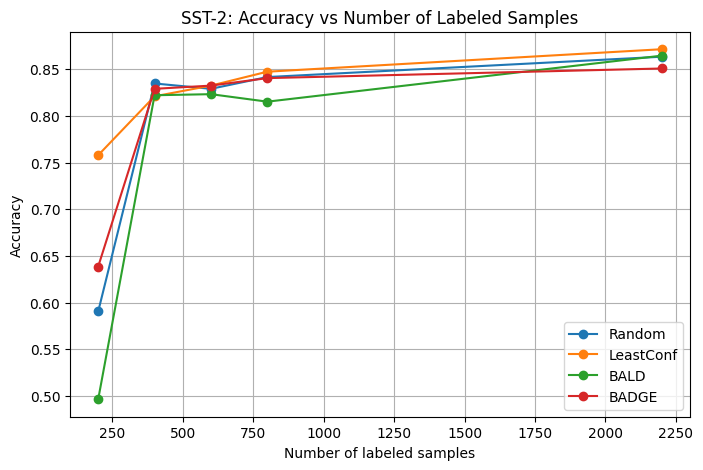

In [ ]:
import matplotlib.pyplot as plt

summaries = {
    "Random": summary_rand,
    "LeastConf": summary_lc,
    "BALD": summary_bald,
    "BADGE": summary_badge
}

plt.figure(figsize=(8,5))

for name, data in summaries.items():
    xs = sorted(data.keys())
    ys = [data[k]["acc"] for k in xs]
    plt.plot(xs, ys, marker='o', label=name)

plt.title("SST-2: Accuracy vs Number of Labeled Samples")
plt.xlabel("Number of labeled samples")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


### 3.2 AG News Базовые стратегии

In [ ]:


histories_ag_news = run_all_strategies_for_dataset(
    dataset_key="ag_news",
    standardized_datasets=standardized_datasets,
    cfg=AL_CFG,
    prefix="ag_news",
)



=== AL EXPERIMENT: dataset=ag_news, strategy=random ===

=== AL EXPERIMENT: dataset=ag_news, strategy=random ===
Num classes: 4, eval split: test
Pool size (subsampled): 10000 (original train: 120000)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


Initial labeled: 200
[Iter 00] labeled= 200 | acc=0.8113 | macro_f1=0.8103 | cost_human=1000.0


/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1002: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


[Iter 01] labeled= 400 | acc=0.8057 | macro_f1=0.8008 | cost_human=2000.0


/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1002: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


In [ ]:
history_ag_news_bald = run_al_experiment_one(
    dataset_key="ag_news",
    standardized_datasets=standardized_datasets,
    strategy_name="bald",
    cfg=AL_CFG,
    experiment_name="ag_news_bald",
)


=== AL EXPERIMENT: dataset=ag_news, strategy=bald ===
Num classes: 4, eval split: test
Pool size (subsampled): 10000 (original train: 120000)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

[Iter 08] labeled=1800 | acc=0.9017 | macro_f1=0.9016 | cost_human=9000.0


/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1002: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


[Iter 09] labeled=2000 | acc=0.9028 | macro_f1=0.9024 | cost_human=10000.0


/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1002: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


[Iter 10] labeled=2200 | acc=0.9078 | macro_f1=0.9075 | cost_human=11000.0
History saved to:
  /content/drive/MyDrive/al_two_oracles/logs/ag_news_bald_history.json
  /content/drive/MyDrive/al_two_oracles/logs/ag_news_bald_history.csv


In [ ]:
from transformers import DistilBertForSequenceClassification

if not hasattr(DistilBertForSequenceClassification, "_orig_forward"):
    DistilBertForSequenceClassification._orig_forward = DistilBertForSequenceClassification.forward

def _forward_patched(self, input_ids=None, attention_mask=None, **kwargs):
    return DistilBertForSequenceClassification._orig_forward(
        self,
        input_ids=input_ids,
        attention_mask=attention_mask,
        **{k: v for k, v in kwargs.items() if k != "token_type_ids"}
    )

DistilBertForSequenceClassification.forward = _forward_patched

print("Patched DistilBertForSequenceClassification.forward (idempotent).")


Patched DistilBertForSequenceClassification.forward (idempotent).


In [ ]:
history_ag_news_badge = run_al_experiment_one(
    dataset_key="ag_news",
    standardized_datasets=standardized_datasets,
    strategy_name="badge",
    cfg=AL_CFG,
    experiment_name="ag_news_badge",
)


=== AL EXPERIMENT: dataset=ag_news, strategy=badge ===
Num classes: 4, eval split: test
Pool size (subsampled): 10000 (original train: 120000)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

[Iter 08] labeled=1800 | acc=0.9007 | macro_f1=0.9004 | cost_human=9000.0


100%|██████████| 10000/10000 [00:33<00:00, 298.52it/s]
/usr/local/lib/python3.12/dist-packages/small_text/utils/clustering.py:53: UserWarning: kmeans_plusplus returned identical cluster centers.
  warnings.warn('kmeans_plusplus returned identical cluster centers.')


[Iter 09] labeled=2000 | acc=0.8997 | macro_f1=0.8995 | cost_human=10000.0


100%|██████████| 10000/10000 [00:33<00:00, 297.81it/s]
/usr/local/lib/python3.12/dist-packages/small_text/utils/clustering.py:53: UserWarning: kmeans_plusplus returned identical cluster centers.
  warnings.warn('kmeans_plusplus returned identical cluster centers.')


[Iter 10] labeled=2200 | acc=0.9008 | macro_f1=0.9007 | cost_human=11000.0
History saved to:
  /content/drive/MyDrive/al_two_oracles/logs/ag_news_badge_history.json
  /content/drive/MyDrive/al_two_oracles/logs/ag_news_badge_history.csv


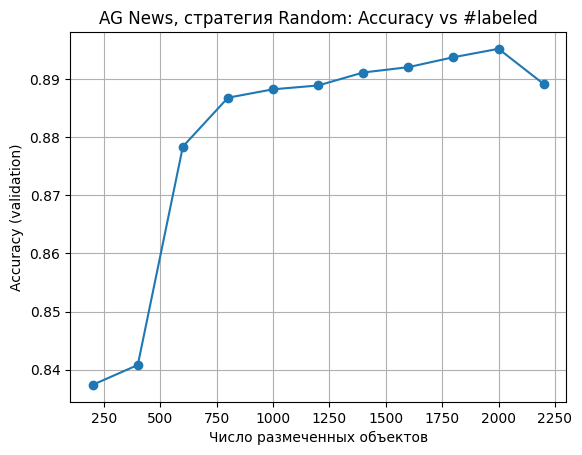

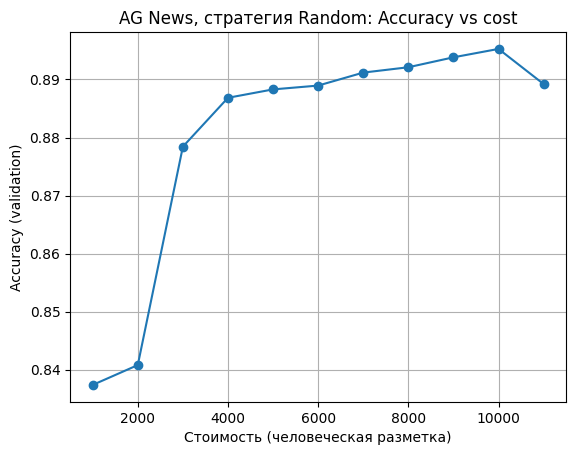

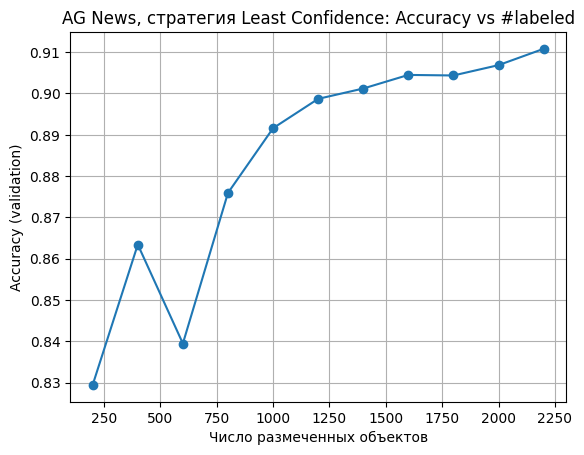

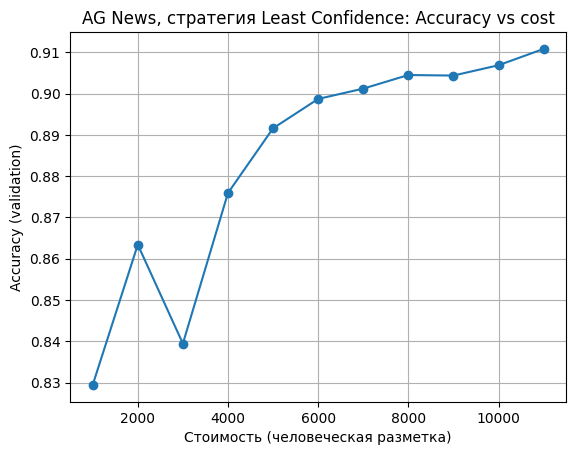

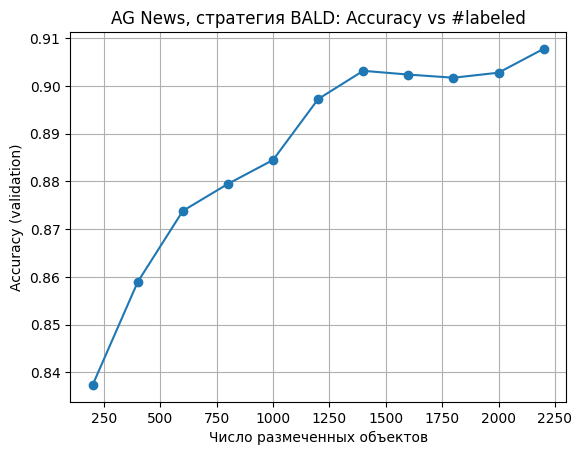

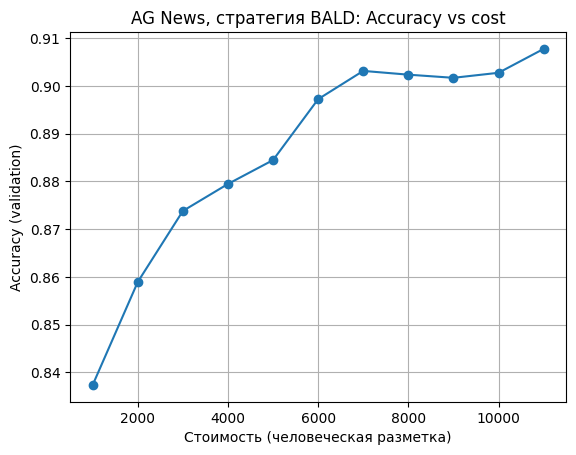

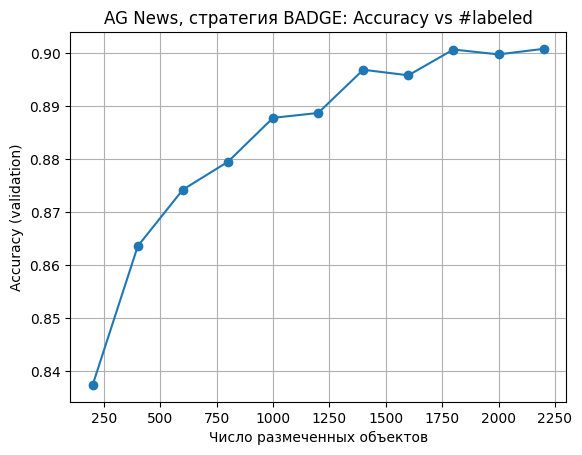

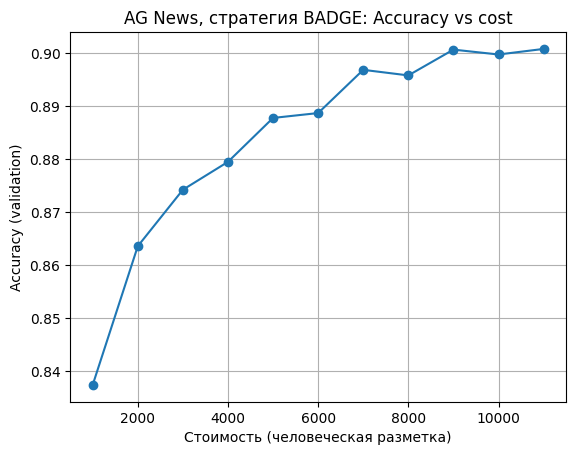

In [ ]:
# AG News: Random / LC / BALD / BADGE

plot_history("ag_news_random", "AG News, стратегия Random")
plot_history("ag_news_least_conf", "AG News, стратегия Least Confidence")
plot_history("ag_news_bald", "AG News, стратегия BALD")
plot_history("ag_news_badge", "AG News, стратегия BADGE")


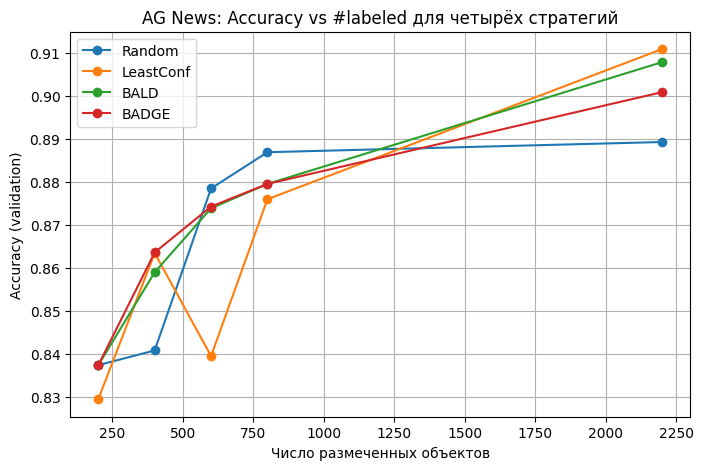

In [ ]:
# Сводный график

df_ag_random = pd.read_csv(os.path.join(LOG_DIR, "ag_news_random_history.csv"))
df_ag_lc  = pd.read_csv(os.path.join(LOG_DIR, "ag_news_least_conf_history.csv"))
df_ag_bald = pd.read_csv(os.path.join(LOG_DIR, "ag_news_bald_history.csv"))
df_ag_badge  = pd.read_csv(os.path.join(LOG_DIR, "ag_news_badge_history.csv"))

summary_ag_rand = summarize_cold_start(df_ag_random)
summary_ag_lc = summarize_cold_start(df_ag_lc)
summary_ag_bald  = summarize_cold_start(df_ag_bald)
summary_ag_badge = summarize_cold_start(df_ag_badge)

summaries_ag = {
    "Random": summary_ag_rand,
    "LeastConf": summary_ag_lc,
    "BALD": summary_ag_bald,
    "BADGE": summary_ag_badge,
}

plt.figure(figsize=(8,5))
for name, data in summaries_ag.items():
    xs = sorted(data.keys())
    ys = [data[k]["acc"] for k in xs]
    plt.plot(xs, ys, marker="o", label=name)

plt.xlabel("Число размеченных объектов")
plt.ylabel("Accuracy (validation)")
plt.title("AG News: Accuracy vs #labeled для четырёх стратегий")
plt.grid(True)
plt.legend()
plt.show()


### 3.3 HateXplain Базовые стратегии


In [ ]:

histories_hatexplain = run_all_strategies_for_dataset(
    dataset_key="hatexplain",
    standardized_datasets=standardized_datasets,
    cfg=AL_CFG,
    prefix="hatexplain",
)

history_hatexplain_random  = histories_hatexplain["random"]
history_hatexplain_lc = histories_hatexplain["least_conf"]
history_hatexplain_bald = histories_hatexplain["bald"]
history_hatexplain_badge = histories_hatexplain["badge"]


=== AL EXPERIMENT: dataset=hatexplain, strategy=random ===

=== AL EXPERIMENT: dataset=hatexplain, strategy=random ===
Num classes: 3, eval split: validation
Pool size (subsampled): 10000 (original train: 15383)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


Initial labeled: 200
[Iter 00] labeled= 200 | acc=0.4688 | macro_f1=0.3927 | cost_human=1000.0
[Iter 01] labeled= 400 | acc=0.5291 | macro_f1=0.4078 | cost_human=2000.0
[Iter 02] labeled= 600 | acc=0.5838 | macro_f1=0.5044 | cost_human=3000.0
[Iter 03] labeled= 800 | acc=0.5895 | macro_f1=0.4838 | cost_human=4000.0
[Iter 04] labeled=1000 | acc=0.6067 | macro_f1=0.5187 | cost_human=5000.0
[Iter 05] labeled=1200 | acc=0.6327 | macro_f1=0.5759 | cost_human=6000.0
[Iter 06] labeled=1400 | acc=0.6249 | macro_f1=0.5613 | cost_human=7000.0
[Iter 07] labeled=1600 | acc=0.6374 | macro_f1=0.6113 | cost_human=8000.0
[Iter 08] labeled=1800 | acc=0.6462 | macro_f1=0.6173 | cost_human=9000.0
[Iter 09] labeled=2000 | acc=0.6472 | macro_f1=0.6178 | cost_human=10000.0
[Iter 10] labeled=2200 | acc=0.6571 | macro_f1=0.6393 | cost_human=11000.0
History saved to:
  /content/drive/MyDrive/al_two_oracles/logs/hatexplain_random_history.json
  /content/drive/MyDrive/al_two_oracles/logs/hatexplain_random_histor

/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


Initial labeled: 200
[Iter 00] labeled= 200 | acc=0.3564 | macro_f1=0.3339 | cost_human=1000.0
[Iter 01] labeled= 400 | acc=0.5125 | macro_f1=0.4163 | cost_human=2000.0
[Iter 02] labeled= 600 | acc=0.4194 | macro_f1=0.2600 | cost_human=3000.0
[Iter 03] labeled= 800 | acc=0.5416 | macro_f1=0.5110 | cost_human=4000.0
[Iter 04] labeled=1000 | acc=0.5957 | macro_f1=0.5280 | cost_human=5000.0
[Iter 05] labeled=1200 | acc=0.6098 | macro_f1=0.5867 | cost_human=6000.0
[Iter 06] labeled=1400 | acc=0.6212 | macro_f1=0.5911 | cost_human=7000.0
[Iter 07] labeled=1600 | acc=0.6290 | macro_f1=0.6046 | cost_human=8000.0
[Iter 08] labeled=1800 | acc=0.6306 | macro_f1=0.6072 | cost_human=9000.0
[Iter 09] labeled=2000 | acc=0.6197 | macro_f1=0.5886 | cost_human=10000.0
[Iter 10] labeled=2200 | acc=0.6441 | macro_f1=0.6273 | cost_human=11000.0
History saved to:
  /content/drive/MyDrive/al_two_oracles/logs/hatexplain_least_conf_history.json
  /content/drive/MyDrive/al_two_oracles/logs/hatexplain_least_con

...

/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1002: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


[Iter 05] labeled=1200 | acc=0.5822 | macro_f1=0.4693 | cost_human=6000.0


/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1002: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


[Iter 06] labeled=1400 | acc=0.6186 | macro_f1=0.5590 | cost_human=7000.0


/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1002: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


In [ ]:
history_hatexplain_bald = run_al_experiment_one(
    dataset_key="hatexplain",
    standardized_datasets=standardized_datasets,
    strategy_name="bald",
    cfg=AL_CFG,
    experiment_name="hatexplain_bald",
)

In [ ]:
history_hatexplain_badge = run_al_experiment_one(
    dataset_key="hatexplain",
    standardized_datasets=standardized_datasets,
    strategy_name="badge",
    cfg=AL_CFG,
    experiment_name="hatexplain_badge",
)

In [ ]:
# hatexplain: Random / LC / BALD / BADGE

plot_history("hatexplain_random", "HateXplain, стратегия Random")
plot_history("hatexplain_least_conf", "HateXplain, стратегия Least Confidence")
plot_history("hatexplain_bald", "HateXplain, стратегия BALD")
plot_history("hatexplain_badge", "HateXplain, стратегия BADGE")


In [ ]:
# Сводный график

df_ht_random = pd.read_csv(os.path.join(LOG_DIR, "hatexplain_random_history.csv"))
df_ht_lc  = pd.read_csv(os.path.join(LOG_DIR, "hatexplain_least_conf_history.csv"))
df_ht_bald = pd.read_csv(os.path.join(LOG_DIR, "hatexplain_bald_history.csv"))
df_ht_badge  = pd.read_csv(os.path.join(LOG_DIR, "hatexplain_badge_history.csv"))

summary_ht_rand = summarize_cold_start(df_ht_random)
summary_ht_lc = summarize_cold_start(df_ht_lc)
summary_ht_bald  = summarize_cold_start(df_ht_bald)
summary_ht_badge = summarize_cold_start(df_ht_badge)

summaries_ht = {
    "Random": summary_ht_rand,
    "LeastConf": summary_ht_lc,
    "BALD": summary_ht_bald,
    "BADGE": summary_ht_badge,
}

plt.figure(figsize=(8,5))
for name, data in summariesht.items():
    xs = sorted(data.keys())
    ys = [data[k]["acc"] for k in xs]
    plt.plot(xs, ys, marker="o", label=name)

plt.xlabel("Число размеченных объектов")
plt.ylabel("Accuracy (validation)")
plt.title("HateXplain: Accuracy vs #labeled для четырёх стратегий")
plt.grid(True)
plt.legend()
plt.show()


## Блок 4. Интеграция с GIGACHAT

In [ ]:
# from google.colab import userdata
# userdata.get('GIGACHAT_AUTH_KEY')

In [ ]:
import os
from gigachat import GigaChat

GIGACHAT_AUTH_KEY = "GIGACHAT_AUTH_KEY"
SCOPE = "GIGACHAT_API_PERS"

client = GigaChat(
    credentials='MDE5YTg3MDEtMjBjYy03YzJlLTg3ZDQtMTYxNGYxNmYwMDc1OjM4ZmM3NWQwLWMxMjYtNGM4Yy1hZTlmLWNmZjI1Mzc1MDU1OA==',
    scope=SCOPE,
    model="GigaChat",
    verify_ssl_certs=False
)


In [ ]:
LABEL_SPACES = {
    "sst2": {
        "id2label": {0: "negative", 1: "positive"},
        "label2id": {"negative": 0, "positive": 1},
        "task_description": "Классификация тональности английских предложений."
    },
    "ag_news": {
        "id2label": {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"},
        "label2id": {"World": 0, "Sports": 1, "Business": 2, "Sci/Tech": 3},
        "task_description": "Классификация новостных заголовков по тематическим рубрикам."
    },
    "hatexplain": {
        "id2label": {0: "hatespeech", 1: "normal", 2: "offensive"},
        "label2id": {"hatespeech": 0, "normal": 1, "offensive": 2},
        "task_description": "Классификация коротких текстов по наличию и типу токсичной речи."
    },
}


Пример функции для одного текста:

In [ ]:
import json
import re

def llm_label_single(text: str, dataset_key: str, client) -> int:
    info = LABEL_SPACES[dataset_key]
    label2id = info["label2id"]
    labels = list(label2id.keys())
    labels_lower = {k.lower(): v for k, v in label2id.items()}
    task_desc = info["task_description"]

    prompt = (
        "Ты выступаешь как аккуратный разметчик датасета по классификации текста.\n"
        "Твоя задача — отнести текст ровно к одному из классов.\n"
        "Отвечай строго в формате JSON: {\"label\": \"<имя_класса>\"} без лишнего текста.\n"
        "Никогда не придумывай новые классы. Если текст кажется нейтральным или неоднозначным,\n"
        "всё равно выбери один из перечисленных классов, который ближе всего по смыслу.\n\n"
        f"{task_desc}\n\n"
        f"Возможные классы: {', '.join(labels)}.\n\n"
        f"Текст:\n\"\"\"\n{text}\n\"\"\"\n\n"
        "Выбери наиболее подходящий класс и верни только JSON. Кроме JSON ни в коем случем ничего больше не дописывай в ответе!!!"
    )

    response = client.chat(prompt)
    msg = response.choices[0].message
    content = msg.content.strip()

    if content.startswith("```"):
        content = content.strip("`").strip()
        if content.lower().startswith("json"):
            content = content[4:].strip()

    json_str = None
    start = content.find("{")
    end = content.find("}", start + 1) if start != -1 else -1
    if start != -1 and end != -1:
        json_str = content[start:end + 1]
    else:
        json_str = content

    try:
        data = json.loads(json_str)
        label_name = str(data.get("label", "")).strip()
    except Exception:
        m = re.search(r'"label"\s*:\s*"([^"]+)"', content)
        if m:
            label_name = m.group(1).strip()
        else:
            label_name = content.strip()

    label_key = label_name.lower()

    if label_key in labels_lower:
        return labels_lower[label_key]

    if dataset_key == "sst2":
        if "neutral" in label_key:
            if "negative" in labels_lower:
                return labels_lower["negative"]

        if "pos" in label_key and "positive" in labels_lower:
            return labels_lower["positive"]
        if "neg" in label_key and "negative" in labels_lower:
            return labels_lower["negative"]

    print(f"[WARN] Unknown LLM label '{label_name}', falling back to '{labels[0]}'")
    first_label_id = label2id[labels[0]]
    return first_label_id


In [ ]:
def llm_label_batch(texts, dataset_key: str, client: "GigaChat") -> list[int]:
    labels = []
    for t in texts:
        labels.append(llm_label_single(t, dataset_key, client))
    return labels


In [ ]:
import numpy as np

def get_oracle_labels(
    queried_indices,
    pool_ds,
    pool_hf,
    dataset_key: str,
    oracle_type: str,
    gigachat_client=None,
):
    """
    Возвращает метки для индексов queried_indices в зависимости от типа оракула.

    oracle_type:
      - "human"  -> берём gold labels из pool_ds
      - "llm"    -> спрашиваем LLM (GigaChat) через llm_label_batch(...)
    """
    if oracle_type == "human":
        # идеальный человек: просто gold labels
        return pool_ds.y[queried_indices]

    elif oracle_type == "llm":
        if gigachat_client is None:
            raise ValueError("gigachat_client is None, а oracle_type='llm'")

        # pool_hf — это HF Dataset с полем "text"
        texts = [pool_hf[int(i)]["text"] for i in queried_indices]
        labels_llm = llm_label_batch(texts, dataset_key, gigachat_client)
        return np.array(labels_llm, dtype=np.int64)

    else:
        raise ValueError(f"Unknown oracle_type={oracle_type}")


In [ ]:
from typing import Dict, Any, List, Optional

def run_al_experiment_one_oracles(
    dataset_key: str,
    standardized_datasets: Dict[str, Any],
    strategy_name: str,
    cfg: ALConfig = AL_CFG,
    experiment_name: Optional[str] = None,
    save_checkpoints: bool = False,
    save_history_flag: bool = True,
    oracle_type: str = "human",      # 'human' | 'llm' | 'hybrid'
    hybrid_k: Optional[int] = None,  # сколько итераций считать "LLM-фазой" при oracle_type='hybrid'
    gigachat_client=None,            # экземпляр клиента GigaChat для LLM-оракула
):
    """
    dataset_key: 'sst2' / 'ag_news' / 'hatexplain'
    strategy_name: 'random', 'least_conf', 'bald', 'badge' (если используешь)
    oracle_type:
        - 'human'  -> gold labels
        - 'llm'    -> все метки даёт LLM
        - 'hybrid' -> первые hybrid_k итераций LLM, дальше human
    """
    if experiment_name is None:
        experiment_name = f"{dataset_key}_{strategy_name}_{oracle_type}"

    print(
        f"\n=== AL EXPERIMENT: dataset={dataset_key}, "
        f"strategy={strategy_name}, oracle={oracle_type}, exp={experiment_name} ==="
    )

    ds_std = standardized_datasets[dataset_key]
    train_hf = ds_std["train"]
    eval_hf, eval_name = get_eval_split(ds_std)

    num_classes = len(set(train_hf["label"]))
    print(f"Num classes: {num_classes}, eval split: {eval_name}")

    # --- ограничиваем пул по cfg.pool_size ---
    pool_hf, pool_indices = subsample_pool(train_hf, cfg.pool_size, cfg.seed)
    print(f"Pool size (subsampled): {len(pool_hf)} (original train: {len(train_hf)})")

    # --- конвертация в TransformersDataset ---
    pool_ds = to_transformers_dataset(pool_hf, num_classes, max_length=cfg.max_length)
    test_ds = to_transformers_dataset(eval_hf, num_classes, max_length=cfg.max_length)

    # --- классификатор и стратегия ---
    clf_factory = make_classifier_factory(num_classes, cfg)
    query_strategy = make_query_strategy(strategy_name, num_classes)

    active_learner = PoolBasedActiveLearner(clf_factory, query_strategy, pool_ds)

    # --- инициализация (начальная разметка) ---
    indices_initial = random_initialization_balanced(
        pool_ds.y, n_samples=cfg.initial_labeled
    )
    y_initial = np.array([pool_ds.y[i] for i in indices_initial])
    active_learner.initialize_data(indices_initial, y_initial)

    print(f"Initial labeled: {len(indices_initial)}")

    history: List[Dict[str, Any]] = []
    indices_labeled = indices_initial.copy()

    for it in range(cfg.iterations + 1):
        # 1) оценка
        metrics = evaluate_on_test(active_learner, test_ds)
        labeled_count = len(indices_labeled)

        # считаем стоимость разметки (пока без раздельного учёта гибрида — это можно позже доработать)
        total_cost_human = labeled_count * cfg.cost_human
        total_cost_llm = labeled_count * cfg.cost_llm

        step_info = dict(
            iter=int(it),
            labeled=int(labeled_count),
            acc=float(metrics["acc"]),
            macro_f1=float(metrics["macro_f1"]),
            cost_human=float(total_cost_human),
            cost_llm=float(total_cost_llm),
        )
        history.append(step_info)

        print(
            f"[Iter {it:02d}] labeled={labeled_count:4d} | "
            f"acc={metrics['acc']:.4f} | macro_f1={metrics['macro_f1']:.4f} | "
            f"cost_human={total_cost_human:.1f}"
        )

        # сохраняем чекпоинт модели после оценки
        if save_checkpoints:
            save_active_learner_checkpoint(active_learner, experiment_name, iteration=it)

        # последняя "итерация-оценка" — дальше не запрашиваем новые примеры
        if it == cfg.iterations:
            break

        # 2) запрос новой порции примеров
        queried_indices = active_learner.query(num_samples=cfg.batch_size)

        # 3) выбираем, какого оракула использовать на этой итерации
        if oracle_type == "hybrid":
            if hybrid_k is None:
                raise ValueError("oracle_type='hybrid', но hybrid_k не задан")
            current_oracle = "llm" if it < hybrid_k else "human"
        else:
            current_oracle = oracle_type

        # 4) получаем метки от текущего оракула
        y_queried = get_oracle_labels(
            queried_indices,
            pool_ds=pool_ds,
            pool_hf=pool_hf,
            dataset_key=dataset_key,
            oracle_type=current_oracle,
            gigachat_client=gigachat_client,
        )

        active_learner.update(y_queried)
        indices_labeled = np.concatenate([indices_labeled, queried_indices])

    if save_history_flag:
        save_history(history, experiment_name)

    return history


In [ ]:
# print(llm_label_single("I love this movie!", "sst2", client))


1


In [ ]:

# from gigachat import GigaChat

# GIGACHAT_AUTH_DATA = "MDE5YTg3MDEtMjBjYy03YzJlLTg3ZDQtMTYxNGYxNmYwMDc1OjM4ZmM3NWQwLWMxMjYtNGM4Yy1hZTlmLWNmZjI1Mzc1MDU1OA=="  # длинная base64-строка

# client = GigaChat(
#     credentials=GIGACHAT_AUTH_DATA,
#     scope="GIGACHAT_API_PERS",
#     verify_ssl_certs=False,
# )

# prompt = "Ты ассистент, ответь одним словом 'OK'. Вопрос: Слышь меня? Ответ:"

# resp = client.chat(prompt)
# msg = resp.choices[0].message
# print(getattr(msg, "content", getattr(msg, "text", msg)))


OK


In [ ]:
AL_CFG_SST2_LLM = ALConfig(
    seed=42,
    pool_size=5000,      # вместо 10000
    initial_labeled=200,
    batch_size=200,
    iterations=5,        # 0..5 -> 200, 400, 600, 800, 1000, 1200
    cost_human=5.0,
    cost_llm=1.0,
    max_length=128,
    num_epochs=3,
    train_batch_size=16,
)


Random + LLM-only (SST-2)

In [ ]:
history_sst2_random_llm = run_al_experiment_one_oracles(
    dataset_key="sst2",
    standardized_datasets=standardized_datasets,
    strategy_name="random",
    cfg=AL_CFG_SST2_LLM,
    experiment_name="sst2_random_llm_only",
    oracle_type="llm",
    hybrid_k=None,
    gigachat_client=client,
)



=== AL EXPERIMENT: dataset=sst2, strategy=random, oracle=llm, exp=sst2_random_llm_only ===
Num classes: 2, eval split: validation
Pool size (subsampled): 5000 (original train: 67349)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


Initial labeled: 200
[Iter 00] labeled= 200 | acc=0.7787 | macro_f1=0.7787 | cost_human=1000.0
[Iter 01] labeled= 400 | acc=0.7993 | macro_f1=0.7959 | cost_human=2000.0
[Iter 02] labeled= 600 | acc=0.8131 | macro_f1=0.8112 | cost_human=3000.0
[WARN] Unknown LLM label 'emotional', falling back to 'negative'
[Iter 03] labeled= 800 | acc=0.8303 | macro_f1=0.8297 | cost_human=4000.0
[Iter 04] labeled=1000 | acc=0.8383 | macro_f1=0.8380 | cost_human=5000.0
[Iter 05] labeled=1200 | acc=0.8142 | macro_f1=0.8136 | cost_human=6000.0
History saved to:
  /content/drive/MyDrive/al_two_oracles/logs/sst2_random_llm_only_history.json
  /content/drive/MyDrive/al_two_oracles/logs/sst2_random_llm_only_history.csv


Random + Hybrid (LLM в cold start -> потом human)

In [ ]:
history_sst2_random_hybrid_k3 = run_al_experiment_one_oracles(
    dataset_key="sst2",
    standardized_datasets=standardized_datasets,
    strategy_name="random",
    cfg=AL_CFG_SST2_LLM,
    experiment_name="sst2_random_hybrid_k3",
    oracle_type="hybrid",
    hybrid_k=3,               # итерации 1,2,3 - LLM; дальше human
    gigachat_client=client,
)



=== AL EXPERIMENT: dataset=sst2, strategy=random, oracle=hybrid, exp=sst2_random_hybrid_k3 ===
Num classes: 2, eval split: validation
Pool size (subsampled): 5000 (original train: 67349)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


Initial labeled: 200
[Iter 00] labeled= 200 | acc=0.5711 | macro_f1=0.4899 | cost_human=1000.0
[Iter 01] labeled= 400 | acc=0.7924 | macro_f1=0.7875 | cost_human=2000.0
[Iter 02] labeled= 600 | acc=0.8291 | macro_f1=0.8284 | cost_human=3000.0
[Iter 03] labeled= 800 | acc=0.8257 | macro_f1=0.8255 | cost_human=4000.0
[Iter 04] labeled=1000 | acc=0.8383 | macro_f1=0.8382 | cost_human=5000.0
[Iter 05] labeled=1200 | acc=0.8498 | macro_f1=0.8497 | cost_human=6000.0
History saved to:
  /content/drive/MyDrive/al_two_oracles/logs/sst2_random_hybrid_k3_history.json
  /content/drive/MyDrive/al_two_oracles/logs/sst2_random_hybrid_k3_history.csv


Least Confidence + LLM-only (SST-2)

In [ ]:
history_sst2_lc_llm = run_al_experiment_one_oracles(
    dataset_key="sst2",
    standardized_datasets=standardized_datasets,
    strategy_name="least_conf",
    cfg=AL_CFG_SST2_LLM,
    experiment_name="sst2_leastconf_llm_only",
    oracle_type="llm",
    hybrid_k=None,
    gigachat_client=client,
)



=== AL EXPERIMENT: dataset=sst2, strategy=least_conf, oracle=llm, exp=sst2_leastconf_llm_only ===
Num classes: 2, eval split: validation
Pool size (subsampled): 5000 (original train: 67349)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


Initial labeled: 200
[Iter 00] labeled= 200 | acc=0.8096 | macro_f1=0.8095 | cost_human=1000.0
[Iter 01] labeled= 400 | acc=0.4908 | macro_f1=0.3292 | cost_human=2000.0
[WARN] Unknown LLM label 'emotional', falling back to 'negative'
[Iter 02] labeled= 600 | acc=0.8005 | macro_f1=0.7972 | cost_human=3000.0
[Iter 03] labeled= 800 | acc=0.8280 | macro_f1=0.8280 | cost_human=4000.0
[Iter 04] labeled=1000 | acc=0.8417 | macro_f1=0.8415 | cost_human=5000.0
[Iter 05] labeled=1200 | acc=0.8406 | macro_f1=0.8405 | cost_human=6000.0
History saved to:
  /content/drive/MyDrive/al_two_oracles/logs/sst2_leastconf_llm_only_history.json
  /content/drive/MyDrive/al_two_oracles/logs/sst2_leastconf_llm_only_history.csv


Least Confidence + Hybrid (LLM в cold start -> потом human)

In [ ]:
history_sst2_lc_hybrid_k3 = run_al_experiment_one_oracles(
    dataset_key="sst2",
    standardized_datasets=standardized_datasets,
    strategy_name="least_conf",
    cfg=AL_CFG_SST2_LLM,
    experiment_name="sst2_leastconf_hybrid_k3",
    oracle_type="hybrid",
    hybrid_k=3,
    gigachat_client=client,
)



=== AL EXPERIMENT: dataset=sst2, strategy=least_conf, oracle=hybrid, exp=sst2_leastconf_hybrid_k3 ===
Num classes: 2, eval split: validation
Pool size (subsampled): 5000 (original train: 67349)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


Initial labeled: 200
[Iter 00] labeled= 200 | acc=0.7007 | macro_f1=0.6789 | cost_human=1000.0
[Iter 01] labeled= 400 | acc=0.8154 | macro_f1=0.8153 | cost_human=2000.0
[Iter 02] labeled= 600 | acc=0.8165 | macro_f1=0.8163 | cost_human=3000.0
[Iter 03] labeled= 800 | acc=0.6468 | macro_f1=0.6049 | cost_human=4000.0
[Iter 04] labeled=1000 | acc=0.8222 | macro_f1=0.8220 | cost_human=5000.0
[Iter 05] labeled=1200 | acc=0.8280 | macro_f1=0.8278 | cost_human=6000.0
History saved to:
  /content/drive/MyDrive/al_two_oracles/logs/sst2_leastconf_hybrid_k3_history.json
  /content/drive/MyDrive/al_two_oracles/logs/sst2_leastconf_hybrid_k3_history.csv


In [ ]:
# BALD, LLM-only
history_sst2_bald_llm = run_al_experiment_one_oracles(
    dataset_key="sst2",
    standardized_datasets=standardized_datasets,
    strategy_name="bald",
    cfg=AL_CFG_SST2_LLM,
    experiment_name="sst2_bald_llm_only",
    oracle_type="llm",
    hybrid_k=None,
    gigachat_client=client,
)

# BALD, hybrid (первые 3 итерации — LLM, дальше human)
history_sst2_bald_hybrid_k3 = run_al_experiment_one_oracles(
    dataset_key="sst2",
    standardized_datasets=standardized_datasets,
    strategy_name="bald",
    cfg=AL_CFG_SST2_LLM,
    experiment_name="sst2_bald_hybrid_k3",
    oracle_type="hybrid",
    hybrid_k=3,
    gigachat_client=client,
)



=== AL EXPERIMENT: dataset=sst2, strategy=bald, oracle=llm, exp=sst2_bald_llm_only ===
Num classes: 2, eval split: validation
Pool size (subsampled): 5000 (original train: 67349)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


Initial labeled: 200
[Iter 00] labeled= 200 | acc=0.7431 | macro_f1=0.7431 | cost_human=1000.0


/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1002: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


[Iter 01] labeled= 400 | acc=0.8234 | macro_f1=0.8224 | cost_human=2000.0


...

[WARN] Unknown LLM label 'mixed', falling back to 'negative'
[Iter 03] labeled= 800 | acc=0.8211 | macro_f1=0.8195 | cost_human=4000.0


/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1002: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


[Iter 04] labeled=1000 | acc=0.8383 | macro_f1=0.8383 | cost_human=5000.0


/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1002: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


[Iter 05] labeled=1200 | acc=0.8245 | macro_f1=0.8245 | cost_human=6000.0
History saved to:
  /content/drive/MyDrive/al_two_oracles/logs/sst2_bald_hybrid_k3_history.json
  /content/drive/MyDrive/al_two_oracles/logs/sst2_bald_hybrid_k3_history.csv


In [ ]:
# Random, hybrid_k1: только первая итерация (после initial) размечается LLM
history_sst2_random_hybrid_k1 = run_al_experiment_one_oracles(
    dataset_key="sst2",
    standardized_datasets=standardized_datasets,
    strategy_name="random",
    cfg=AL_CFG_SST2_LLM,
    experiment_name="sst2_random_hybrid_k1",
    oracle_type="hybrid",
    hybrid_k=1,
    gigachat_client=client,
)

# Random, hybrid_k5: фактически почти LLM-only (все 5 итераций), но с возможностью дообучения человеком на последних шагах
history_sst2_random_hybrid_k5 = run_al_experiment_one_oracles(
    dataset_key="sst2",
    standardized_datasets=standardized_datasets,
    strategy_name="random",
    cfg=AL_CFG_SST2_LLM,
    experiment_name="sst2_random_hybrid_k5",
    oracle_type="hybrid",
    hybrid_k=5,
    gigachat_client=client,
)



=== AL EXPERIMENT: dataset=sst2, strategy=random, oracle=hybrid, exp=sst2_random_hybrid_k1 ===
Num classes: 2, eval split: validation
Pool size (subsampled): 5000 (original train: 67349)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


Initial labeled: 200
[Iter 00] labeled= 200 | acc=0.6342 | macro_f1=0.5876 | cost_human=1000.0
[Iter 01] labeled= 400 | acc=0.7959 | macro_f1=0.7923 | cost_human=2000.0
[Iter 02] labeled= 600 | acc=0.8314 | macro_f1=0.8313 | cost_human=3000.0
[Iter 03] labeled= 800 | acc=0.8268 | macro_f1=0.8268 | cost_human=4000.0
[Iter 04] labeled=1000 | acc=0.8326 | macro_f1=0.8326 | cost_human=5000.0
[Iter 05] labeled=1200 | acc=0.8222 | macro_f1=0.8219 | cost_human=6000.0
History saved to:
  /content/drive/MyDrive/al_two_oracles/logs/sst2_random_hybrid_k1_history.json
  /content/drive/MyDrive/al_two_oracles/logs/sst2_random_hybrid_k1_history.csv

=== AL EXPERIMENT: dataset=sst2, strategy=random, oracle=hybrid, exp=sst2_random_hybrid_k5 ===
Num classes: 2, eval split: validation
Pool size (subsampled): 5000 (original train: 67349)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


Initial labeled: 200
[Iter 00] labeled= 200 | acc=0.4908 | macro_f1=0.3292 | cost_human=1000.0
[Iter 01] labeled= 400 | acc=0.7454 | macro_f1=0.7322 | cost_human=2000.0
[Iter 02] labeled= 600 | acc=0.8280 | macro_f1=0.8275 | cost_human=3000.0
[Iter 03] labeled= 800 | acc=0.8303 | macro_f1=0.8300 | cost_human=4000.0
[Iter 04] labeled=1000 | acc=0.8257 | macro_f1=0.8253 | cost_human=5000.0


ResponseError: (URL('https://gigachat.devices.sberbank.ru/api/v1/chat/completions'), 402, b'{"status":402,"message":"Payment Required"}\n', Headers({'server': 'SynGX', 'date': 'Fri, 12 Dec 2025 10:42:32 GMT', 'content-type': 'application/json; charset=utf-8', 'content-length': '44', 'connection': 'keep-alive', 'access-control-allow-credentials': 'true', 'access-control-allow-headers': 'Origin, X-Requested-With, Content-Type, Accept, Authorization', 'access-control-allow-methods': 'GET, POST, DELETE, OPTIONS', 'access-control-allow-origin': 'https://beta.saluteai.sberdevices.ru', 'x-request-id': 'd3ee0b72-660b-4cec-914f-1fbf9247c5d1', 'x-session-id': '2816d941-ed65-4d87-96e0-985718fdb609', 'allow': 'GET, POST', 'strict-transport-security': 'max-age=31536000; includeSubDomains'}))

In [ ]:
# Least Confidence, hybrid_k1
history_sst2_lc_hybrid_k1 = run_al_experiment_one_oracles(
    dataset_key="sst2",
    standardized_datasets=standardized_datasets,
    strategy_name="least_conf",
    cfg=AL_CFG_SST2_LLM,
    experiment_name="sst2_leastconf_hybrid_k1",
    oracle_type="hybrid",
    hybrid_k=1,
    gigachat_client=client,
)

# Least Confidence, hybrid_k5
history_sst2_lc_hybrid_k5 = run_al_experiment_one_oracles(
    dataset_key="sst2",
    standardized_datasets=standardized_datasets,
    strategy_name="least_conf",
    cfg=AL_CFG_SST2_LLM,
    experiment_name="sst2_leastconf_hybrid_k5",
    oracle_type="hybrid",
    hybrid_k=5,
    gigachat_client=client,
)


In [ ]:
# BALD, hybrid_k1
history_sst2_bald_hybrid_k1 = run_al_experiment_one_oracles(
    dataset_key="sst2",
    standardized_datasets=standardized_datasets,
    strategy_name="bald",
    cfg=AL_CFG_SST2_LLM,
    experiment_name="sst2_bald_hybrid_k1",
    oracle_type="hybrid",
    hybrid_k=1,
    gigachat_client=client,
)

# BALD, hybrid_k5
history_sst2_bald_hybrid_k5 = run_al_experiment_one_oracles(
    dataset_key="sst2",
    standardized_datasets=standardized_datasets,
    strategy_name="bald",
    cfg=AL_CFG_SST2_LLM,
    experiment_name="sst2_bald_hybrid_k5",
    oracle_type="hybrid",
    hybrid_k=5,
    gigachat_client=client,
)


## Блок 5. Diversity

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.cluster import KMeans
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMB_MODEL_NAME = "distilbert-base-uncased"
emb_tokenizer = AutoTokenizer.from_pretrained(EMB_MODEL_NAME)
emb_model = AutoModel.from_pretrained(EMB_MODEL_NAME).to(device)
emb_model.eval()


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSdpaAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [ ]:
def encode_texts_to_embeddings(texts, batch_size: int = 32, max_length: int = 128):
    """
    Кодирует список текстов в CLS-эмбеддинги DistilBERT.
    Возвращает np.array формы [N, hidden_size].
    """
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        enc = emb_tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = emb_model(**enc)
            # CLS-токен у DistilBERT — это первый токен
            cls_emb = outputs.last_hidden_state[:, 0, :]  # [batch, hidden]
            all_embs.append(cls_emb.cpu().numpy())

    return np.concatenate(all_embs, axis=0)


In [ ]:
def select_initial_indices_diversity(pool_hf, n_samples: int, seed: int = 42, max_length: int = 128):
    """
    Выбирает n_samples индексов из HF Dataset (pool_hf) на основе k-means по CLS-эмбеддингам.
    """
    texts = [pool_hf[i]["text"] for i in range(len(pool_hf))]
    print(f"Encoding {len(texts)} texts to embeddings for diversity init...")
    emb = encode_texts_to_embeddings(texts, batch_size=32, max_length=max_length)

    print("Running KMeans...")
    kmeans = KMeans(n_clusters=n_samples, random_state=seed, n_init=10)
    kmeans.fit(emb)

    # Для каждого кластера находим точку, ближайшую к центроиду
    indices = []
    for k in range(n_samples):
        cluster_mask = (kmeans.labels_ == k)
        cluster_indices = np.where(cluster_mask)[0]
        if len(cluster_indices) == 0:
            continue  # на всякий случай
        cluster_embs = emb[cluster_indices]
        center = kmeans.cluster_centers_[k]
        dists = np.linalg.norm(cluster_embs - center, axis=1)
        best_idx = cluster_indices[np.argmin(dists)]
        indices.append(int(best_idx))

    print(f"Selected {len(indices)} initial indices by diversity.")
    return np.array(indices, dtype=np.int64)


In [ ]:
from typing import Dict, Any, List, Optional
import numpy as np

def run_al_experiment_diversity_init(
    strategy_name: str,
    cfg: ALConfig,
    experiment_name: str,
    oracle_type: str = "human",          # 'human' | 'llm' | 'hybrid'
    dataset_key: str = "sst2",
    hybrid_k: Optional[int] = None,
    gigachat_client=None,
    initial_oracle_type: str = "human",  # 'human' | 'llm'
):
    """
    AL-эксперимент с diversity-based инициализацией (KMeans по эмбеддингам),
    с поддержкой разных типов оракулов и честным учётом стоимости.

    strategy_name: 'random' / 'least_conf' / 'bald' / 'badge' (если очень захочешь)
    oracle_type:
      - 'human'  -> все последующие батчи размечает человек
      - 'llm'    -> все батчи размечает LLM
      - 'hybrid' -> первые hybrid_k итераций LLM, дальше человек
    initial_oracle_type:
      - 'human'  -> стартовые 200 меток считаем от человека
      - 'llm'    -> стартовые 200 меток считаем от LLM
    """
    print(
        f"\n=== AL EXPERIMENT (DIVERSITY INIT): dataset={dataset_key}, "
        f"strategy={strategy_name}, oracle={oracle_type}, "
        f"init_oracle={initial_oracle_type}, exp={experiment_name} ==="
    )

    ds_std = standardized_datasets[dataset_key]
    train_hf = ds_std["train"]
    eval_hf, eval_name = get_eval_split(ds_std)

    num_classes = len(set(train_hf["label"]))
    print(f"Num classes: {num_classes}, eval split: {eval_name}")

    # --- пул ---
    pool_hf, pool_indices = subsample_pool(train_hf, cfg.pool_size, cfg.seed)
    print(f"Pool size (subsampled): {len(pool_hf)} (original train: {len(train_hf)})")

    pool_ds = to_transformers_dataset(pool_hf, num_classes, max_length=cfg.max_length)
    test_ds = to_transformers_dataset(eval_hf, num_classes, max_length=cfg.max_length)

    clf_factory = make_classifier_factory(num_classes, cfg)
    query_strategy = make_query_strategy(strategy_name, num_classes)
    active_learner = PoolBasedActiveLearner(clf_factory, query_strategy, pool_ds)

    # --- DIVERSITY-BASED INITIALIZATION ---
    indices_initial = select_initial_indices_diversity(
        pool_hf,
        n_samples=cfg.initial_labeled,
        seed=cfg.seed,
        max_length=cfg.max_length,
    )

    # метки для initial набора
    if initial_oracle_type == "human":
        y_initial = np.array([pool_ds.y[i] for i in indices_initial])
    elif initial_oracle_type == "llm":
        if gigachat_client is None:
            raise ValueError("initial_oracle_type='llm', но gigachat_client=None")
        texts_init = [pool_hf[int(i)]["text"] for i in indices_initial]
        y_initial = np.array(
            llm_label_batch(texts_init, dataset_key, gigachat_client),
            dtype=np.int64,
        )
    else:
        raise ValueError(f"Unknown initial_oracle_type={initial_oracle_type}")

    active_learner.initialize_data(indices_initial, y_initial)
    print(f"Initial labeled (diversity): {len(indices_initial)}")

    # счётчики стоимости
    cum_human_labels = 0
    cum_llm_labels = 0

    if initial_oracle_type == "human":
        cum_human_labels += len(indices_initial)
    else:
        cum_llm_labels += len(indices_initial)

    history: List[Dict[str, Any]] = []
    indices_labeled = indices_initial.copy()

    for it in range(cfg.iterations + 1):
        # 1) оценка
        metrics = evaluate_on_test(active_learner, test_ds)
        labeled_count = len(indices_labeled)

        total_cost = (
            cum_human_labels * cfg.cost_human
            + cum_llm_labels * cfg.cost_llm
        )

        step_info = dict(
            iter=int(it),
            labeled=int(labeled_count),
            acc=float(metrics["acc"]),
            macro_f1=float(metrics["macro_f1"]),
            cum_human_labels=int(cum_human_labels),
            cum_llm_labels=int(cum_llm_labels),
            total_cost=float(total_cost),
        )
        history.append(step_info)

        print(
            f"[Iter {it:02d}] labeled={labeled_count:4d} | "
            f"acc={metrics['acc']:.4f} | macro_f1={metrics['macro_f1']:.4f} | "
            f"human_labels={cum_human_labels} | llm_labels={cum_llm_labels} | "
            f"total_cost={total_cost:.1f}"
        )

        if it == cfg.iterations:
            break

        # 2) запрос новой порции примеров
        queried_indices = active_learner.query(num_samples=cfg.batch_size)

        # 3) выбираем, какого оракула использовать на этой итерации
        if oracle_type == "hybrid":
            if hybrid_k is None:
                raise ValueError("oracle_type='hybrid', но hybrid_k не задан")
            current_oracle = "llm" if it < hybrid_k else "human"
        else:
            current_oracle = oracle_type

        # 4) получаем метки от текущего оракула
        y_queried = get_oracle_labels(
            queried_indices,
            pool_ds=pool_ds,
            pool_hf=pool_hf,
            dataset_key=dataset_key,
            oracle_type=current_oracle,
            gigachat_client=gigachat_client,
        )

        # 5) обновляем счётчики стоимости
        if current_oracle == "human":
            cum_human_labels += len(queried_indices)
        elif current_oracle == "llm":
            cum_llm_labels += len(queried_indices)
        else:
            raise ValueError(f"Unexpected current_oracle={current_oracle}")

        # 6) обновляем AL-модель
        active_learner.update(y_queried)
        indices_labeled = np.concatenate([indices_labeled, queried_indices])

    save_history(history, experiment_name)
    return history


In [ ]:
AL_CFG_SST2_LLM = ALConfig(
    seed=42,
    pool_size=5000,      # вместо 10000
    initial_labeled=200,
    batch_size=200,
    iterations=5,        # 0..5 -> 200, 400, 600, 800, 1000, 1200
    cost_human=5.0,
    cost_llm=1.0,
    max_length=128,
    num_epochs=3,
    train_batch_size=16,
)


In [ ]:
history_sst2_random_diversity_human = run_al_experiment_diversity_init(
    strategy_name="random",
    cfg=AL_CFG_SST2_LLM,
    experiment_name="sst2_random_diversityinit_human",
    oracle_type="human",
    dataset_key="sst2",
    hybrid_k=None,
    gigachat_client=None,
    initial_oracle_type="human",
)

history_sst2_lc_diversity_human = run_al_experiment_sst2_diversity_init(
    strategy_name="least_conf",
    cfg=AL_CFG_SST2_LLM,
    experiment_name="sst2_leastconf_diversityinit_human",
)




=== AL EXPERIMENT (DIVERSITY INIT): dataset=sst2, strategy=random, oracle=human, exp=sst2_random_diversityinit_human ===
Num classes: 2, eval split: validation
Pool size (subsampled): 5000 (original train: 67349)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


Encoding 5000 texts to embeddings for diversity init...
Running KMeans...
Selected 200 initial indices by diversity.


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


Encoding 5000 texts to embeddings for diversity init...
Running KMeans...
Selected 200 initial indices by diversity.
Initial labeled (diversity): 200
[Iter 00] labeled= 200 | acc=0.6307 | macro_f1=0.5804 | cost_human=1000.0


/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1002: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


[Iter 01] labeled= 400 | acc=0.8257 | macro_f1=0.8256 | cost_human=2000.0


/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1002: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


In [ ]:
history_sst2_bald_diversity_human = run_al_experiment_sst2_diversity_init(
    strategy_name="bald",
    cfg=AL_CFG_SST2_LLM,
    experiment_name="sst2_bald_diversityinit_human",
)


=== AL EXPERIMENT (DIVERSITY INIT): dataset=sst2, strategy=bald, oracle=human, exp=sst2_bald_diversityinit_human ===
Num classes: 2, eval split: validation
Pool size (subsampled): 5000 (original train: 67349)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


Encoding 5000 texts to embeddings for diversity init...
Running KMeans...
Selected 200 initial indices by diversity.


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

[Iter 03] labeled= 800 | acc=0.8360 | macro_f1=0.8360 | cost_human=4000.0


/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1002: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


[Iter 04] labeled=1000 | acc=0.8222 | macro_f1=0.8220 | cost_human=5000.0


/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:1002: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


[Iter 05] labeled=1200 | acc=0.8394 | macro_f1=0.8389 | cost_human=6000.0
History saved to:
  /content/drive/MyDrive/al_two_oracles/logs/sst2_bald_diversityinit_human_history.json
  /content/drive/MyDrive/al_two_oracles/logs/sst2_bald_diversityinit_human_history.csv


Diversity-init + LLM-only

In [ ]:
history_sst2_random_diversity_llm = run_al_experiment_diversity_init(
    strategy_name="random",
    cfg=AL_CFG_SST2_LLM,
    experiment_name="sst2_random_diversityinit_llm",
    oracle_type="llm",
    dataset_key="sst2",
    hybrid_k=None,
    gigachat_client=client,
    initial_oracle_type="llm",   # стартовые 200 тоже размечает LLM
)


=== AL EXPERIMENT (DIVERSITY INIT): dataset=sst2, strategy=random, oracle=llm, init_oracle=llm, exp=sst2_random_diversityinit_llm ===
Num classes: 2, eval split: validation
Pool size (subsampled): 5000 (original train: 67349)
Encoding 5000 texts to embeddings for diversity init...
Running KMeans...
Selected 200 initial indices by diversity.


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Initial labeled (diversity): 200
[Iter 00] labeled= 200 | acc=0.4908 | macro_f1=0.3292 | human_labels=0 | llm_labels=200 | total_cost=200.0
[Iter 01] labeled= 400 | acc=0.6284 | macro_f1=0.5778 | human_labels=0 | llm_labels=400 | total_cost=400.0
[Iter 02] labeled= 600 | acc=0.8050 | macro_f1=0.8029 | human_labels=0 | llm_labels=600 | total_cost=600.0
[Iter 03] labeled= 800 | acc=0.7787 | macro_f1=0.7743 | human_labels=0 | llm_labels=800 | total_cost=800.0
[Iter 04] labeled=1000 | acc=0.7982 | macro_f1=0.7945 | human_labels=0 | llm_labels=1000 | total_cost=1000.0
[Iter 05] labeled=1200 | acc=0.8200 | macro_f1=0.8185 | human_labels=0 | llm_labels=1200 | total_cost=1200.0
History saved to:
  /content/drive/MyDrive/al_two_oracles/logs/sst2_random_diversityinit_llm_history.json
  /content/drive/MyDrive/al_two_oracles/logs/sst2_random_diversityinit_llm_history.csv


Diversity-init + LLM-only


In [ ]:
history_sst2_random_diversity_hybrid_k3 = run_al_experiment_diversity_init(
    strategy_name="random",
    cfg=AL_CFG_SST2_LLM,
    experiment_name="sst2_random_diversityinit_hybrid_k3",
    oracle_type="hybrid",
    dataset_key="sst2",
    hybrid_k=3,                   # 3 итерации LLM, потом human
    gigachat_client=client,
    initial_oracle_type="human",  # например, стартовые 200 считаем человеческими
)



=== AL EXPERIMENT (DIVERSITY INIT): dataset=sst2, strategy=random, oracle=hybrid, init_oracle=human, exp=sst2_random_diversityinit_hybrid_k3 ===
Num classes: 2, eval split: validation
Pool size (subsampled): 5000 (original train: 67349)


/usr/local/lib/python3.12/dist-packages/small_text/utils/annotations.py:67: ExperimentalWarning: The function from_arrays is experimental and maybe subject to change soon.
  warnings.warn(f'The {subject} {func_or_class.__name__} is experimental '


Encoding 5000 texts to embeddings for diversity init...
Running KMeans...
Selected 200 initial indices by diversity.
Initial labeled (diversity): 200
[Iter 00] labeled= 200 | acc=0.6101 | macro_f1=0.5431 | human_labels=200 | llm_labels=0 | total_cost=1000.0
[Iter 01] labeled= 400 | acc=0.8326 | macro_f1=0.8311 | human_labels=200 | llm_labels=200 | total_cost=1200.0
[Iter 02] labeled= 600 | acc=0.8188 | macro_f1=0.8181 | human_labels=200 | llm_labels=400 | total_cost=1400.0
[Iter 03] labeled= 800 | acc=0.8257 | macro_f1=0.8256 | human_labels=200 | llm_labels=600 | total_cost=1600.0
[Iter 04] labeled=1000 | acc=0.8257 | macro_f1=0.8257 | human_labels=400 | llm_labels=600 | total_cost=2600.0
[Iter 05] labeled=1200 | acc=0.8291 | macro_f1=0.8291 | human_labels=600 | llm_labels=600 | total_cost=3600.0
History saved to:
  /content/drive/MyDrive/al_two_oracles/logs/sst2_random_diversityinit_hybrid_k3_history.json
  /content/drive/MyDrive/al_two_oracles/logs/sst2_random_diversityinit_hybrid_k3

In [ ]:
print(llm_label_single("I love this movie!", "sst2", client))

1


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Путь к логам — если у тебя уже есть LOG_DIR, этот блок можно пропустить
LOG_DIR = "/content/drive/MyDrive/al_two_oracles/logs"


def load_history(exp_name: str) -> pd.DataFrame:
    """Читает CSV вида <exp_name>_history.csv из LOG_DIR.
       Если файла нет, возвращает None.
    """
    path = os.path.join(LOG_DIR, f"{exp_name}_history.csv")
    if not os.path.exists(path):
        print(f"[WARN] history csv not found: {path}")
        return None
    df = pd.read_csv(path)
    return df


def get_cost_column(df: pd.DataFrame) -> str:
    """Выбираем, по какому столбцу рисовать 'стоимость':
       сначала total_cost (для LLM/гибридов), иначе cost_human.
    """
    if "total_cost" in df.columns:
        return "total_cost"
    elif "cost_human" in df.columns:
        return "cost_human"
    else:
        raise ValueError("No suitable cost column found in history dataframe")


In [ ]:
def plot_oracle_comparison_sst2(
    strategy_name: str,
    human_exp: str | None,
    llm_exp: str | None,
    hybrid_exp: str | None,
    title_prefix: str
):
    """
    Рисует два графика для одной стратегии:
      1) accuracy vs #labeled
      2) accuracy vs cost
    для разных типов оракулов (human / llm / hybrid), если соответствующие
    эксперименты существуют.
    """
    experiments = {
        "human": human_exp,
        "llm-only": llm_exp,
        "hybrid (k=3)": hybrid_exp,
    }

    dfs = {}
    for label, exp_name in experiments.items():
        if exp_name is None:
            continue
        df = load_history(exp_name)
        if df is not None:
            dfs[label] = df

    if not dfs:
        print(f"[WARN] no histories found for {strategy_name}")
        return

    # --- 1. Accuracy vs #labeled ---
    plt.figure(figsize=(6,4))
    for label, df in dfs.items():
        plt.plot(df["labeled"], df["acc"], marker="o", label=label)
    plt.xlabel("Число размеченных объектов")
    plt.ylabel("Accuracy (validation)")
    plt.title(f"{title_prefix}: accuracy vs #labeled")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- 2. Accuracy vs cost ---
    plt.figure(figsize=(6,4))
    for label, df in dfs.items():
        cost_col = get_cost_column(df)
        plt.plot(df[cost_col], df["acc"], marker="o", label=label)
    plt.xlabel("Суммарная стоимость разметки")
    plt.ylabel("Accuracy (validation)")
    plt.title(f"{title_prefix}: accuracy vs cost")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


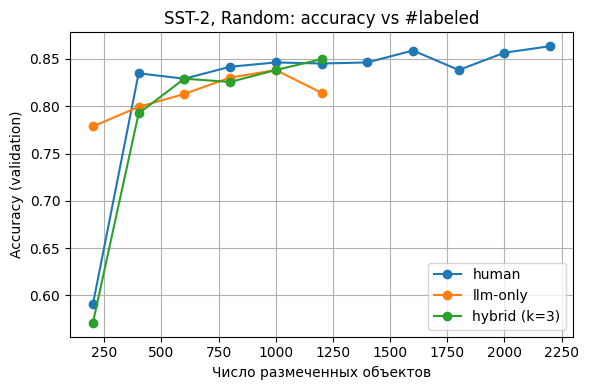

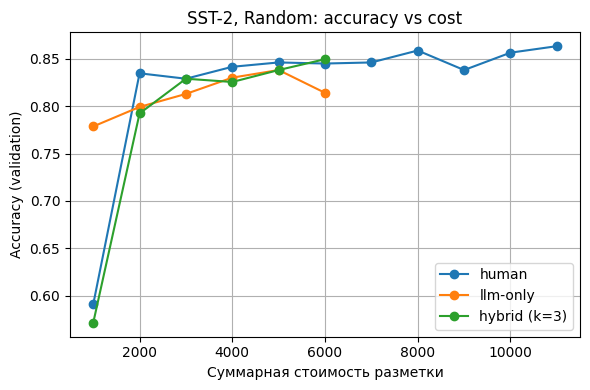

[WARN] history csv not found: /content/drive/MyDrive/al_two_oracles/logs/sst2_least_conf_history.csv


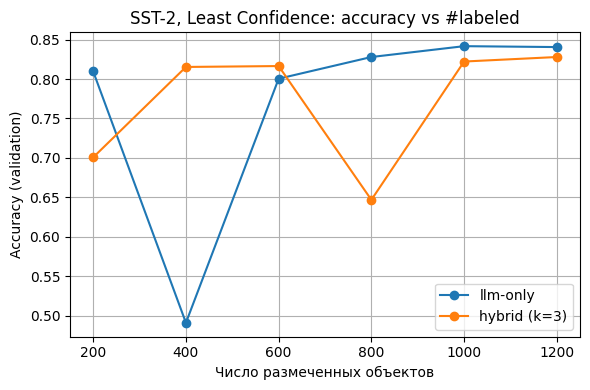

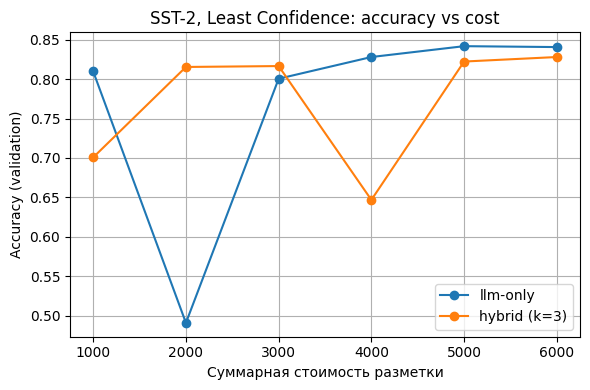

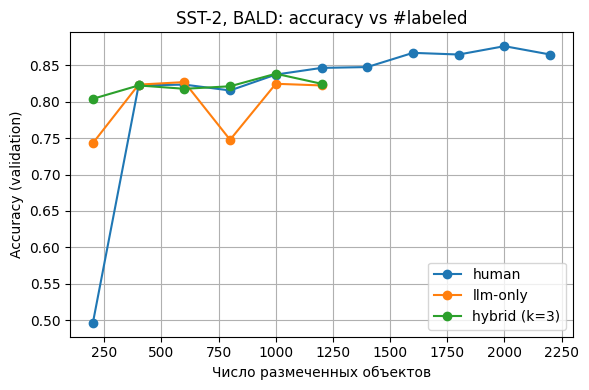

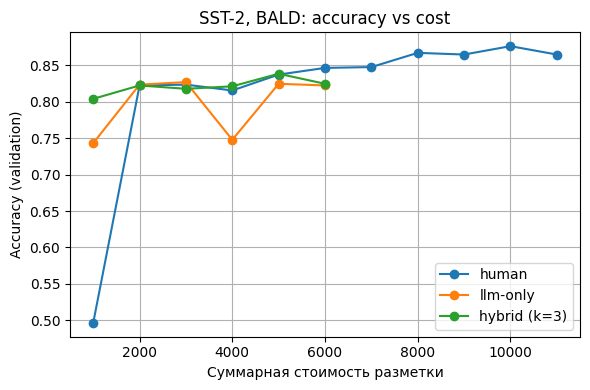

In [ ]:
# Random: human vs LLM-only vs hybrid_k3
plot_oracle_comparison_sst2(
    strategy_name="random",
    human_exp="sst2_random",                 # human-only базовый эксперимент
    llm_exp="sst2_random_llm_only",
    hybrid_exp="sst2_random_hybrid_k3",
    title_prefix="SST-2, Random"
)

# Least Confidence
plot_oracle_comparison_sst2(
    strategy_name="least_conf",
    human_exp="sst2_least_conf",
    llm_exp="sst2_leastconf_llm_only",
    hybrid_exp="sst2_leastconf_hybrid_k3",
    title_prefix="SST-2, Least Confidence"
)

# BALD
plot_oracle_comparison_sst2(
    strategy_name="bald",
    human_exp="sst2_bald",
    llm_exp="sst2_bald_llm_only",
    hybrid_exp="sst2_bald_hybrid_k3",
    title_prefix="SST-2, BALD"
)


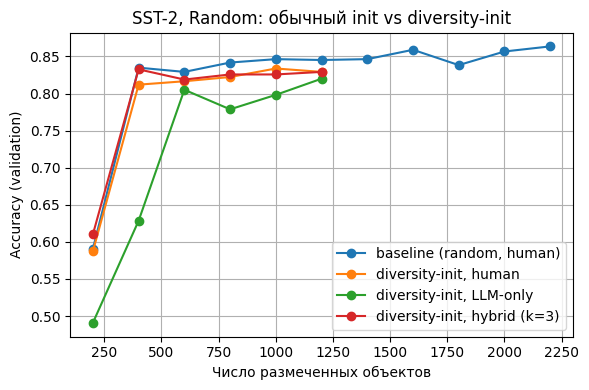

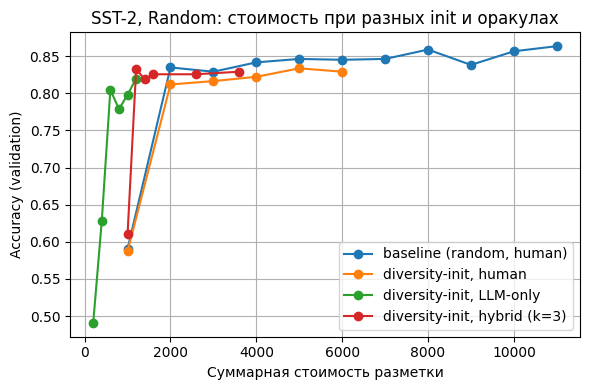

In [ ]:
def plot_diversity_init_comparison_sst2():
    experiments = {
        "baseline (random, human)": "sst2_random",
        "diversity-init, human": "sst2_random_diversityinit_human",
        "diversity-init, LLM-only": "sst2_random_diversityinit_llm",
        "diversity-init, hybrid (k=3)": "sst2_random_diversityinit_hybrid_k3",
    }

    dfs = {}
    for label, exp_name in experiments.items():
        df = load_history(exp_name)
        if df is not None:
            dfs[label] = df

    # --- Accuracy vs #labeled ---
    plt.figure(figsize=(6,4))
    for label, df in dfs.items():
        plt.plot(df["labeled"], df["acc"], marker="o", label=label)
    plt.xlabel("Число размеченных объектов")
    plt.ylabel("Accuracy (validation)")
    plt.title("SST-2, Random: обычный init vs diversity-init")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Accuracy vs cost (total_cost / cost_human) ---
    plt.figure(figsize=(6,4))
    for label, df in dfs.items():
        cost_col = get_cost_column(df)
        plt.plot(df[cost_col], df["acc"], marker="o", label=label)
    plt.xlabel("Суммарная стоимость разметки")
    plt.ylabel("Accuracy (validation)")
    plt.title("SST-2, Random: стоимость при разных init и оракулах")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_diversity_init_comparison_sst2()
